In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, underride, configure_plot_style, AIBM_COLORS, code_to_who_country, code_to_wef_country

configure_plot_style()

In [3]:
def load_and_inventory(filename):
    """
    Load a WHO health indicator CSV file and print inventory information.
    
    Filters the data to include only records from year 2000 to 2019 (excludes 2020+)
    to avoid COVID-19 pandemic distortions, and country-level data (excludes regional aggregates).
    Adds a 'CountryName' column mapping country codes to country names using code_to_who_country.
    
    Parameters
    ----------
    filename : str
        Path to the CSV file containing WHO health indicator data.
        
    Returns
    -------
    df : pandas.DataFrame
        Filtered DataFrame containing country-level data from 2000-2019,
        with an additional 'CountryName' column.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Filter to 2000-2019 to exclude COVID-19 pandemic years (2020+)
    df = pd.read_csv(filename).query('Year >= 2000 and Year <= 2019 and CountryCode == "COUNTRY"')
    
    # Add country name column using code_to_who_country mapping
    # The 'Country' column contains country codes (e.g., 'USA', 'GBR')
    df['CountryName'] = df['Country'].map(code_to_who_country)
    
    print(df.shape)

    try:
        print(df['IndicatorCode'].unique())
        print(df['IndicatorName'].unique())
    except KeyError:
        pass

    sexes = df['Sex'].unique()
    print(sexes)
    print(df['Comments'].unique())
    years = df['Year'].unique()
    print(years)
    print(df['Country'].unique())
    
    return df, years

In [4]:
from functools import reduce

def compute_gender_gap(df, value_col, sexes):
    """
    Return a DataFrame with separate columns for each sex and a gap column,
    handling cases where one or more sexes are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Must include 'Country', 'Year', 'Sex', and the specified value_col.
        May also include 'CountryName' which will be preserved.
    value_col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of values in the 'Sex' column, e.g. ['SEX_MLE', 'SEX_FMLE'].
        The first two entries are used to compute the gap (second - first).

    Returns
    -------
    df_by_sex : pandas.DataFrame
        Contains columns for each available sex and a gap column (second - first)
        if both sexes are present. Also includes 'CountryName' (added via mapping) and 'Year'.
    """
    # Determine which columns to keep
    # Base columns: Country, Year, and the value column (which will be renamed)
    # CountryName will be added later via mapping
    base_cols = ['Country', 'Year']
    
    dfs = []

    # Build a renamed DataFrame for each sex, only if it exists
    # Select only the columns we want to keep before merging
    for sex in sexes:
        temp = df[df['Sex'] == sex]
        if not temp.empty:
            # Select only the columns we need: base columns + value column
            cols_to_select = base_cols + [value_col]
            temp = temp[cols_to_select].copy()
            # Rename the value column to include the sex
            temp = temp.rename(columns={value_col: f"{value_col}_{sex}"})
            dfs.append(temp)

    # If no data at all, return empty DataFrame
    if not dfs:
        return pd.DataFrame(columns=['Country', 'Year'])

    # Merge all available sexes
    merge_on = ['Country', 'Year']
    df_by_sex = reduce(lambda left, right: left.merge(right, on=merge_on, how='outer'), dfs)

    # Compute the gap only if both sexes are available
    if len(sexes) >= 2:
        col1 = f"{value_col}_{sexes[0]}"
        col2 = f"{value_col}_{sexes[1]}"
        if col1 in df_by_sex.columns and col2 in df_by_sex.columns:
            df_by_sex[f"{value_col}_Gap"] = df_by_sex[col2] - df_by_sex[col1]

    df_by_sex['CountryName'] = df_by_sex['Country'].map(code_to_who_country)

    return df_by_sex


In [5]:
def summarize_gap(df, col, sexes=None):
    """
    Compute gender gap and create summary visualization using most recent data per country.
    
    Computes gender gaps using compute_gender_gap, then selects the most recent year
    available for each country (which may differ by country). Creates a scatter plot
    comparing values between sexes (if multiple sexes are provided).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing health indicator data with 'Country', 'Year', 'Sex',
        and the value column specified by col. May also include 'CountryName'.
    col : str
        Name of the column containing the numeric value to compare between sexes.
    sexes : list of str
        List of sex values to compare (e.g., ['Male', 'Female']).
        
    Returns
    -------
    df_gap : pandas.DataFrame
        DataFrame with gender gap computed for all years. Includes 'CountryName' and 'Year' columns.
    df_recent : pandas.DataFrame
        DataFrame with the most recent available year for each country, indexed by Country.
        Includes 'CountryName' and 'Year' columns.
    """
    sexes = sexes or ['Male', 'Female']
    df_gap = compute_gender_gap(df, col, sexes)
    
    # Get the most recent year for each country
    most_recent_years = df_gap.groupby('Country')['Year'].max().reset_index()
    df_recent = df_gap.merge(most_recent_years, on=['Country', 'Year'])
    
    # Set index to Country, but keep CountryName and Year as columns
    df_recent = df_recent.set_index('Country')
    
    if len(sexes) > 1:
        cols = [f'{col}_{sex}' for sex in sexes]
        high = df_recent[cols].max().max()
        domain = [0, high]
        scatter_plot(df_recent, cols, domain)
        decorate(xlabel=f'{col}, Male', 
                 ylabel=f'{col}, Female', title=f'All Countries')
    
    return df_gap, df_recent

In [6]:
def scatter_plot(df, cols, domain, **options):
    """
    Create a scatter plot comparing two columns with a diagonal reference line.
    
    Plots the values from two columns against each other, with a diagonal
    reference line (y=x) to show equality. Uses a square aspect ratio by default.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country, containing the columns to plot.
    cols : list of str
        List of two column names to plot on x and y axes.
    domain : list of float
        Two-element list [min, max] defining the plot domain for both axes.
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, ylabel, title).
    """
    plt.plot(df[cols[0]], df[cols[1]], '.', color=AIBM_COLORS['crimson'])
    plt.plot(domain, domain, color='gray', alpha=0.5)
    
    underride(options, aspect='equal')
    decorate(**options)

In [7]:
from utils import oecd_codes
import warnings

def get_oecd(df):
    """
    Filter DataFrame to include only OECD member countries.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame indexed by country codes.
        
    Returns
    -------
    pandas.DataFrame
        Subset of the input DataFrame containing only OECD countries.
        
    Note
    -----
    Warns if any expected OECD countries are missing from the data.
    """
    available_countries = set(df.index)
    expected_oecd = set(oecd_codes)
    missing_countries = expected_oecd - available_countries
    
    if missing_countries:
        warnings.warn(
            f"Missing {len(missing_countries)} OECD countries in data: {sorted(missing_countries)}",
            UserWarning
        )
    
    return df.loc[df.index.intersection(oecd_codes)]

In [8]:
def summarize_years(predictor_dfs):
    """
    Create a summary table of year coverage for each indicator in predictor_dfs.
    
    Parameters
    ----------
    predictor_dfs : dict
        Dictionary mapping indicator names to DataFrames containing predictor data.
        Each DataFrame should have a 'Year' column.
        
    Returns
    -------
    pandas.DataFrame
        Summary table with columns: Indicator, Low_Year, High_Year, Most_Common_Year,
        N_Countries_Most_Common, Total_Countries.
    """
    year_summary = []
    
    for name, df in predictor_dfs.items():
        years = df['Year'].dropna()
        if len(years) > 0:
            year_counts = years.value_counts()
            most_common_year = year_counts.index[0]
            n_countries_most_common = year_counts.iloc[0]
            
            year_summary.append({
                'Indicator': name,
                'Low_Year': int(years.min()),
                'High_Year': int(years.max()),
                'Most_Common_Year': int(most_common_year),
                'N_Countries_Most_Common': int(n_countries_most_common),
                'Total_Countries': len(df)
            })
        else:
            year_summary.append({
                'Indicator': name,
                'Low_Year': np.nan,
                'High_Year': np.nan,
                'Most_Common_Year': np.nan,
                'N_Countries_Most_Common': 0,
                'Total_Countries': len(df)
            })
            
    return pd.DataFrame(year_summary)

In [9]:
from empiricaldist import Cdf

def plot_cdfs(df, label='', **options):
    """
    Plot cumulative distribution functions (CDFs) for columns ending in 'ale'.
    
    Creates CDF plots for all columns in the DataFrame that end with 'ale'
    (typically 'Male' and 'Female' columns). Each CDF is plotted with a label
    combining the column name and the provided label.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing numeric columns to plot as CDFs.
    label : str, optional
        Additional label text to append to each CDF plot label (default: '').
    **options : dict
        Additional keyword arguments for plot customization.
    """
    cols = [col for col in df.columns if col.endswith('ale')]
    for col in cols:
        vals = df[col].dropna()
        if vals.count() == 0:
            break
        cdf = Cdf.from_seq(df[col])
        cdf.plot(label=f'{col} {label}', **options)

In [10]:
def plot_distributions(recent, **options):
    """
    Plot CDFs comparing all countries vs OECD countries.
    
    Creates cumulative distribution function plots for both all countries
    and OECD countries subset, allowing comparison of distributions.
    
    Parameters
    ----------
    recent : pandas.DataFrame
        DataFrame indexed by country codes, containing columns ending in 'ale'
        (typically 'Male' and 'Female' columns).
    **options : dict
        Additional keyword arguments passed to decorate() for plot customization
        (e.g., xlabel, title). The ylabel is automatically set to 'CDF'.
    """
    plot_cdfs(recent, label='All countries')
    plot_cdfs(get_oecd(recent), label='OECD')
    
    # Extract indicator name from column names (remove _Male or _Female suffix)
    cols = [col for col in recent.columns if col.endswith('ale')]
    if cols:
        # Get the first column and extract the indicator name
        first_col = cols[0]
        # Remove _Male or _Female suffix to get the indicator name
        indicator_name = first_col.rsplit('_')[:-1] if '_' in first_col else first_col
        xlabel = indicator_name
    else:
        xlabel = ''
    
    underride(options, xlabel=xlabel, ylabel='CDF')
    decorate(**options)

## WHO HALE data

**Healthy Life Expectancy (HALE) at birth** - The average number of years that a person can expect to live in "full health" by taking into account years lived in less than full health due to disease and/or injury. This is the **target variable** for the analysis. The gender gap (Female HALE - Male HALE) measures the difference in healthy life expectancy between women and men.

**Indicator Code**: WHOSIS_000002  
**Relevance**: Direct measure of the outcome we're trying to explain. Gender differences in HALE reflect the cumulative impact of all mortality and morbidity factors that differentially affect men and women.

Downloaded using the GHO OData API (who_data.py)

https://www.who.int/data/gho/info/gho-odata-api

In [11]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG'
 'POL' 'PRI' 'PRK' 'PRT' 'PRY' 'PSE' 'QAT'

In [12]:
d = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male', }
hale['Sex'] = hale['Sex'].replace(d)

In [13]:
hale.head()

,Country,CountryCode,Year,Sex,HALE_Years,HALE_Low,HALE_High,Comments,DataSource,CountryName
0,AFG,COUNTRY,2000,Both,46.027950,44.939602,47.308578,NaN,NaN,Afghanistan
1,AFG,COUNTRY,2001,Both,46.116121,44.907570,47.033098,NaN,NaN,Afghanistan
2,AFG,COUNTRY,2002,Both,47.184852,46.147952,48.308520,NaN,NaN,Afghanistan
3,AFG,COUNTRY,2003,Both,47.977953,47.016452,48.976006,NaN,NaN,Afghanistan
4,AFG,COUNTRY,2004,Both,48.324761,47.311935,49.325042,NaN,NaN,Afghanistan


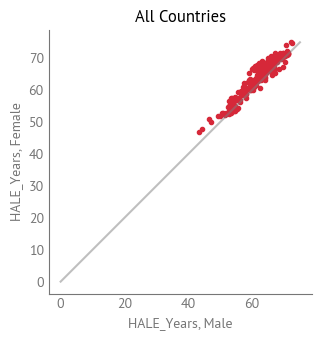

In [14]:
col = 'HALE_Years'
year = years[-1]
hale_gap, hale_recent = summarize_gap(hale, col)

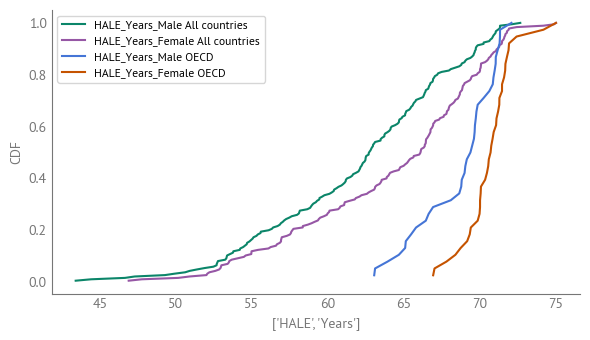

In [15]:
plot_distributions(hale_recent)

## Smoking

**Age-standardized current tobacco smoking prevalence (%)** - Percentage of population aged 15+ who currently smoke any tobacco product, age-standardized for cross-country comparison.

**Indicator Code**: M_Est_smk_curr_std  
**Relevance**: Historically, men have had significantly higher smoking rates than women. Smoking is a major contributor to cardiovascular disease, lung cancer, and respiratory diseases. As smoking rates have converged between genders in some countries, the life expectancy gap has narrowed, suggesting smoking is one of the most important modifiable factors contributing to the HALE gender gap.

In [16]:
filename = '../data/who_smoking_data.csv'
smoking, years = load_and_inventory(filename)

(2475, 12)
['M_Est_smk_curr_std']
['Age-standardized current tobacco smoking prevalence']
['Both sexes' 'Female' 'Male']
[nan 'The most recent survey was conducted in 2013. This is a projection.'
 'The most recent survey was conducted in 2011-12. This is a projection.'
 'The most recent survey was conducted in 2012. This is a projection.'
 'The most recent survey was conducted in 2014. This is a projection.']
[2000 2005 2007 2010 2015]
['AFG' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN'
 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB' 'BRN'
 'BTN' 'BWA' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COK' 'COL'
 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DNK' 'DOM' 'DZA' 'ECU' 'EGY'
 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'GBR' 'GEO' 'GHA' 'GMB' 'GNB' 'GRC'
 'GTM' 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL'
 'ISR' 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 

In [17]:
smoking.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SmokingPrevalence,SmokingPrevalence_Low,SmokingPrevalence_High,Comments,DataSource,CountryName
0,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2000,Both sexes,22.5,10.5,34.4,NaN,NaN,Afghanistan
1,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2005,Both sexes,17.9,9.6,26.3,NaN,NaN,Afghanistan
2,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2007,Both sexes,16.3,9.4,23.3,NaN,NaN,Afghanistan
3,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2010,Both sexes,14.5,9.6,19.4,NaN,NaN,Afghanistan
4,M_Est_smk_curr_std,Age-standardized current tobacco smoking preva...,AFG,COUNTRY,2015,Both sexes,11.8,8.0,15.6,NaN,NaN,Afghanistan


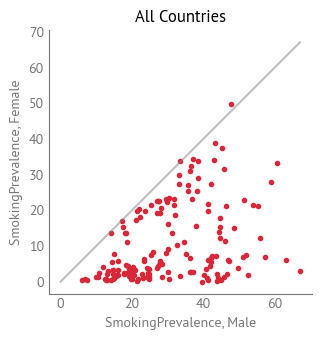

In [18]:
col = 'SmokingPrevalence'
year = years[-1]
smoking_gap, smoking_recent = summarize_gap(smoking, col)

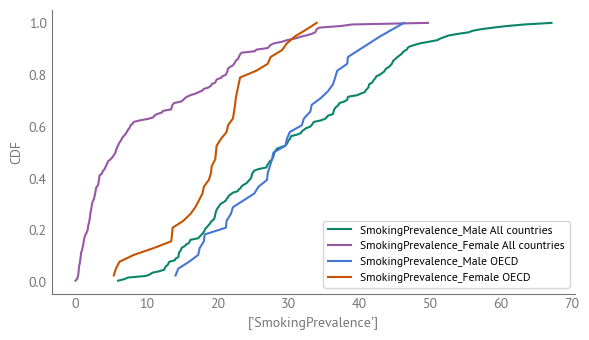

In [19]:
plot_distributions(smoking_recent)

## Suicide

**Age-standardized suicide rates (per 100,000 population)** - Deaths from intentional self-harm, age-standardized for cross-country comparison.

**Indicator Code**: MH_12  
**Relevance**: Suicide rates are typically higher in men across most countries, directly contributing to the gender gap in mortality. Suicide reflects mental health and social factors that differentially affect men and women, and is strongly linked to mortality.

In [20]:
filename = '../data/who_suicide_rates.csv'
suicide, years = load_and_inventory(filename)

(11100, 12)
['MH_12']
['Age-standardized suicide rates (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK'

In [21]:
suicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,SuicideRate,SuicideRate_Low,SuicideRate_High,Comments,DataSource,CountryName
0,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2000,Both sexes,7.185717,3.764944,12.084243,NaN,NaN,Afghanistan
1,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2001,Both sexes,7.270323,3.817979,12.215665,NaN,NaN,Afghanistan
2,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2002,Both sexes,7.112670,3.821785,11.814730,NaN,NaN,Afghanistan
3,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2003,Both sexes,7.043811,3.856506,12.002093,NaN,NaN,Afghanistan
4,MH_12,Age-standardized suicide rates (per 100 000 po...,AFG,COUNTRY,2004,Both sexes,7.025987,3.889151,12.129586,NaN,NaN,Afghanistan


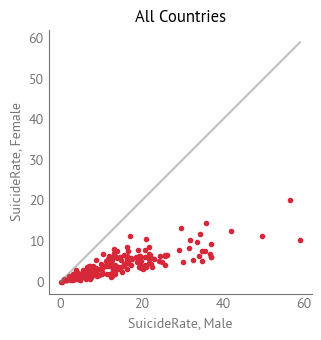

In [22]:
col = 'SuicideRate'
year = years[-1]
suicide_gap, suicide_recent = summarize_gap(suicide, col)

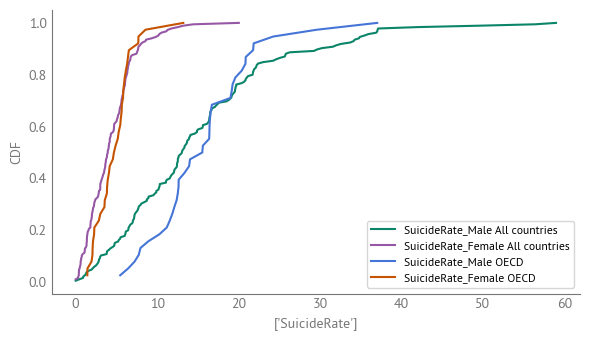

In [23]:
plot_distributions(suicide_recent)

## Alcohol

**Alcohol-attributable all-cause deaths per 100,000 (age-standardized)** - Deaths from all causes that are attributable to alcohol consumption, including direct alcohol-related deaths and alcohol-attributable deaths from other causes (e.g., accidents, liver disease).

**Indicator Code**: SA_0000001832  
**Relevance**: Men typically have higher rates of alcohol consumption and alcohol-related diseases. Alcohol contributes to liver disease, accidents, and various health conditions, directly impacting mortality. Age-standardized rates match HALE methodology for cross-country comparison.

In [24]:
filename = '../data/who_alcohol_death_rates.csv'
alcohol, years = load_and_inventory(filename)

(540, 12)
['SA_0000001832']
['Alcohol-attributable all-cause deaths per 100,000, age standardized']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN

In [25]:
alcohol.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,AlcoholDeathRate,AlcoholDeathRate_Low,AlcoholDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Both sexes,4.949863,4.002665,6.983689,NaN,NaN,Afghanistan
1,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Female,4.002300,2.527392,6.215428,NaN,NaN,Afghanistan
2,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AFG,COUNTRY,2019,Male,5.914343,4.479561,9.296961,NaN,NaN,Afghanistan
3,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Both sexes,88.707178,63.949144,114.463780,NaN,NaN,Angola
4,SA_0000001832,"Alcohol-attributable all-cause deaths per 100,...",AGO,COUNTRY,2019,Female,34.885563,26.543712,47.578170,NaN,NaN,Angola


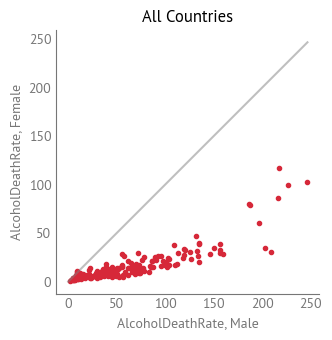

In [26]:
col = 'AlcoholDeathRate'
year = years[-1]
alcohol_gap, alcohol_recent = summarize_gap(alcohol, col)

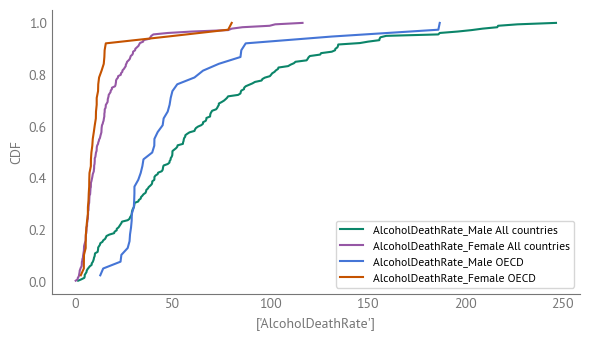

In [27]:
plot_distributions(alcohol_recent)

## Poison

**Mortality rate attributed to unintentional poisoning (per 100,000 population)** - Deaths from accidental poisonings from chemicals, drugs, and other substances.

**Indicator Code**: SDGPOISON  
**Relevance**: Men often have higher rates of accidental deaths, including poisonings. This reflects occupational hazards and risk-taking behaviors that contribute to the gender gap in mortality. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [28]:
filename = '../data/who_poisoning_rates.csv'
poison, years = load_and_inventory(filename)

(11100, 12)
['SDGPOISON']
['Mortality rate attributed to unintentional poisoning (per 100 000 population)']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NO

In [29]:
poison.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,PoisoningRate,PoisoningRate_Low,PoisoningRate_High,Comments,DataSource,CountryName
0,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2000,Both sexes,3.272761,1.091069,6.816218,NaN,NaN,Afghanistan
1,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2001,Both sexes,3.351724,1.157869,6.926548,NaN,NaN,Afghanistan
2,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2002,Both sexes,3.038659,0.946774,6.704357,NaN,NaN,Afghanistan
3,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2003,Both sexes,3.689834,1.521052,7.401055,NaN,NaN,Afghanistan
4,SDGPOISON,Mortality rate attributed to unintentional poi...,AFG,COUNTRY,2004,Both sexes,3.681742,1.573983,7.347575,NaN,NaN,Afghanistan


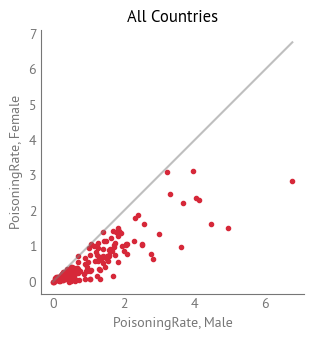

In [30]:
col = 'PoisoningRate'
year = years[-1]
poison_gap, poison_recent = summarize_gap(poison, col)

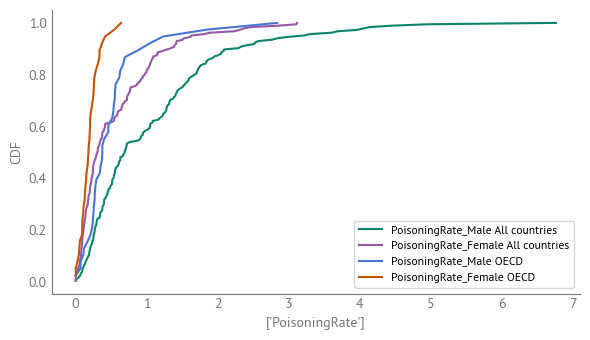

In [31]:
plot_distributions(poison_recent)

## Traffic

**Road traffic crash deaths, age-standardized death rates (15+), per 100,000 population** - Deaths from road traffic accidents, age-standardized for ages 15+.

**Indicator Code**: SA_0000001459  
**Relevance**: Road traffic deaths are typically 2-4 times higher in men across most countries, making it a major contributor to the gender gap in mortality. Reflects higher exposure to driving (including occupational exposure), occupational hazards, and potentially risk-taking behaviors. Age-standardized rates for ages 15+ match HALE methodology.

In [32]:
filename = '../data/who_road_traffic_death_rates.csv'
traffic, years = load_and_inventory(filename)

(540, 12)
['SA_0000001459']
['Road traffic crash deaths, age-standardized death rates (all ages), per 100,000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA'
 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PNG' 'POL'
 'PRK' 'PRT' 'PRY' 'QAT' 'ROU'

In [33]:
traffic.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,RoadTrafficDeathRate,RoadTrafficDeathRate_Low,RoadTrafficDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Both sexes,19.806936,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Female,8.323253,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AFG,COUNTRY,2019,Male,30.823815,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Both sexes,30.060828,NaN,NaN,NaN,NaN,Angola
4,SA_0000001459,"Road traffic crash deaths, age-standardized de...",AGO,COUNTRY,2019,Female,18.692964,NaN,NaN,NaN,NaN,Angola


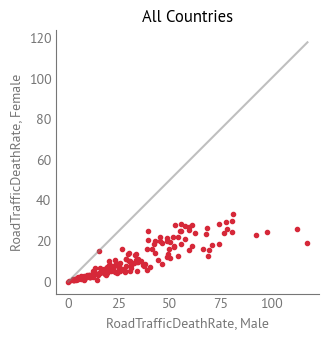

In [34]:
col = 'RoadTrafficDeathRate'
year = years[-1]
traffic_gap, traffic_recent = summarize_gap(traffic, col)

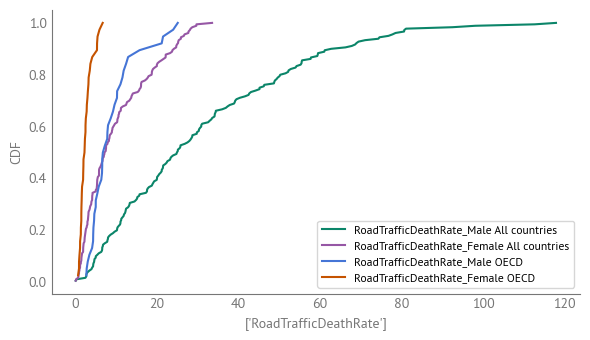

In [35]:
plot_distributions(traffic_recent)

## Maternal mortality

**Maternal mortality ratio (per 100,000 live births)** - Deaths of women during pregnancy, childbirth, or within 42 days of termination of pregnancy, per 100,000 live births.

**Indicator Code**: MDG_0000000026  
**Relevance**: Critical for understanding cases where the HALE gender gap is small due to high female mortality, especially in lower-income countries. High maternal mortality can significantly reduce the HALE gender gap by lowering female life expectancy. Inherently female-specific, so only female values are used in analysis.

In [36]:
filename = '../data/who_maternal_mortality_ratio.csv'
maternal, years = load_and_inventory(filename)

(3900, 12)
['MDG_0000000026']
['Maternal mortality ratio (per 100 000 live births)']
['Female']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ'
 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NLD' 'NOR' 'NPL

In [37]:
maternal.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,MaternalMortalityRatio,MaternalMortalityRatio_Low,MaternalMortalityRatio_High,Comments,DataSource,CountryName
0,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2000,Female,1371.645908,937.495878,1828.321863,NaN,NaN,Afghanistan
1,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2001,Female,1310.954923,906.872935,1734.166876,NaN,NaN,Afghanistan
2,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2002,Female,1262.516681,884.408915,1652.739115,NaN,NaN,Afghanistan
3,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2003,Female,1201.381450,857.173518,1567.186347,NaN,NaN,Afghanistan
4,MDG_0000000026,Maternal mortality ratio (per 100 000 live bir...,AFG,COUNTRY,2004,Female,1166.469374,849.256289,1515.271527,NaN,NaN,Afghanistan


In [38]:
col = 'MaternalMortalityRatio'
year = years[-1]
maternal_gap, maternal_recent = summarize_gap(maternal, col, sexes=['Female'])

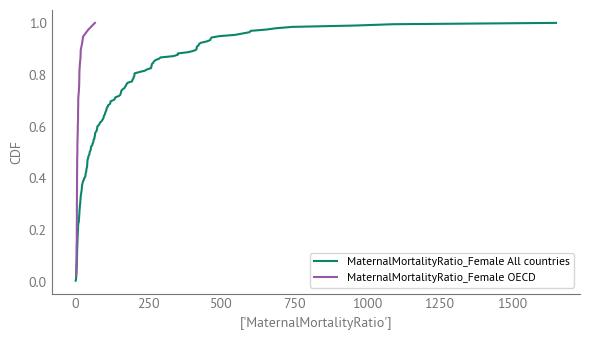

In [39]:
plot_distributions(maternal_recent)

## Homicide

**Estimates of rates of homicides per 100,000 population** - Deaths from intentional homicide, including estimates with confidence intervals.

**Indicator Code**: VIOLENCE_HOMICIDERATE  
**Relevance**: Homicide rates are typically much higher in men across most countries, making it a major contributor to the gender gap in mortality. Homicide reflects violence, conflict, and social factors that differentially affect men and women. Has excellent temporal coverage (2000-2021) and country coverage (196 countries).

In [40]:
filename = '../data/who_homicide_rates.csv'
homicide, years = load_and_inventory(filename)

(11100, 12)
['VIOLENCE_HOMICIDERATE']
['Estimates of rates of homicides per 100 000 population']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG' 'MOZ' 'MRT' 'MUS' 'MWI' 'MYS' 'NAM' 'NER'
 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'N

In [41]:
homicide.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,HomicideRate,HomicideRate_Low,HomicideRate_High,Comments,DataSource,CountryName
0,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2000,Both sexes,10.433863,5.581236,16.844870,NaN,NaN,Afghanistan
1,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2001,Both sexes,10.617865,5.678589,17.162430,NaN,NaN,Afghanistan
2,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2002,Both sexes,10.953708,6.568415,16.902796,NaN,NaN,Afghanistan
3,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2003,Both sexes,10.781847,6.539156,16.757218,NaN,NaN,Afghanistan
4,VIOLENCE_HOMICIDERATE,Estimates of rates of homicides per 100 000 po...,AFG,COUNTRY,2004,Both sexes,10.135798,5.742813,16.420052,NaN,NaN,Afghanistan


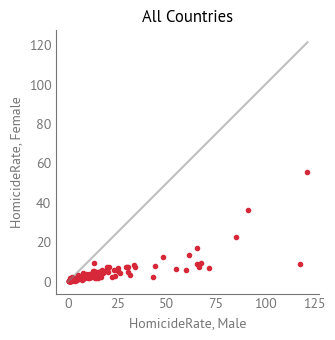

In [42]:
col = 'HomicideRate'
year = years[-1]
homicide_gap, homicide_recent = summarize_gap(homicide, col)

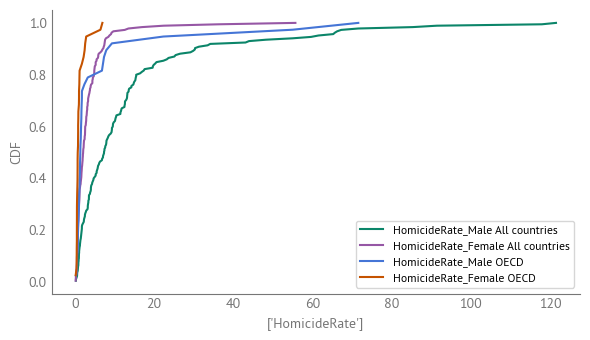

In [43]:
plot_distributions(homicide_recent)

## Intimate Partner Violence

**Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months (%)** - Prevalence indicator measuring the percentage of women experiencing intimate partner violence.

**Indicator Code**: SDGIPV  
**Relevance**: Note: This is a **prevalence indicator** (percentage), not a direct death rate. IPV affects women's health indirectly through mental health impacts, injuries, and other health consequences. It may contribute to the gender gap in HALE through its effects on women's physical and mental health, though the relationship is complex and indirect. Inherently female-specific, so only female values are used in analysis.

In [44]:
filename = '../data/who_ipv_prevalence.csv'
ipv, years = load_and_inventory(filename)

(558, 12)
['SDGIPV']
['Proportion of ever-partnered women and girls aged 15-49 years subjected to physical and/or sexual violence by a current or former intimate partner in the previous 12 months']
['Female']
['DHS '
 'calculated by FRA based on available country data from the 2012 FRA Violence against women: an EU-wide Survey  Women aged 18-74; definition of physical and sexual violence differs from the standard'
 'Violence against Women Survey 2015 '
 'Calculated by UNFPA based on available country data from the Violence against Women Survey 2015 UNECE methodology; women aged 15+'
 'PAHO 2018 publication Intimate Partner Violence against Women in the Americas: calculated by PAHO based on available country data from the Encuesta de Prevalencia y Caracteristicas de la Violencia contra las Mujeres 2016 ~ENDIREH methodology; women aged 15+; definition of sexual violence differs from the standard'
 'MICS ' 'DHS Currently married'
 'DHS Refers to currently married girls and women'
 'The Co

In [45]:
ipv.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,IPVPrevalence,IPVPrevalence_Low,IPVPrevalence_High,Comments,DataSource,CountryName
18,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.1,NaN,NaN,DHS,NaN,Afghanistan
19,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,45.2,NaN,NaN,DHS,NaN,Afghanistan
20,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,51.9,NaN,NaN,DHS,NaN,Afghanistan
21,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,49.3,NaN,NaN,DHS,NaN,Afghanistan
22,SDGIPV,Proportion of ever-partnered women and girls a...,AFG,COUNTRY,2015,Female,48.6,NaN,NaN,DHS,NaN,Afghanistan


In [46]:
col = 'IPVPrevalence'
year = years[-1]
ipv_gap, ipv_recent = summarize_gap(ipv, col, sexes=['Female'])

/tmp/ipykernel_2424932/2285234875.py:27: UserWarning: Missing 12 OECD countries in data: ['AUS', 'CAN', 'CHE', 'CHL', 'CRI', 'ISL', 'ISR', 'JPN', 'KOR', 'NOR', 'NZL', 'USA']
  warnings.warn(


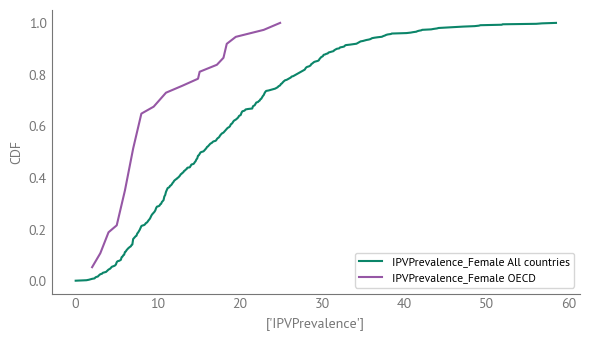

In [47]:
plot_distributions(ipv_recent)

## Under five mortality rate

**Under-five mortality rate (probability of dying by age 5 per 1000 live births)** - Deaths of children under age 5 per 1,000 live births, with gender breakdowns.

**Indicator Code**: MDG_0000000007  
**Relevance**: HALE is calculated from birth, so under-five mortality directly affects HALE calculations. If child mortality differs by gender, it directly contributes to the HALE gender gap. Infant mortality is typically higher in males (biological vulnerability + some behavioral factors). More important in lower-income countries with high child mortality. Note: MDG_0000000007 chosen over u5mr for better data quality when filtered for sex dimension.

In [48]:
filename = '../data/who_u5mr.csv'
u5mr, years = load_and_inventory(filename)

(22600, 12)
['MDG_0000000007']
['Under-five mortality rate (probability of dying by age 5 per 1000 live births)']
['Both sexes' 'Female' 'Male']
[nan
 'Some UN IGME indicators are calculated using population and live birth numbers from the World Population Prospects: The 2024 revision (WPP). The WPP numbers for Cyprus refer to the entire country. However, the underlying data used to calculate mortality rates estimates, provided by the Health Monitoring Unit of the Cyprus Ministry of Health, cover only the government-controlled areas, whereas according to Eurostat, the number of live births in 2023 was 10,295 (https://ec.europa.eu/eurostat/databrowser/view/tps00204/), the population on 1 January 2023 was 920,701 (https://ec.europa.eu/eurostat/databrowser/view/tps00001/), the population under 5 was 49,326,  adolescent population was 99,207 and the number of women of reproductive age was 235,268 (https://doi.org/10.2908/DEMO_PJAN).'
 'The UN IGME estimates are not the official statistics 

In [49]:
u5mr.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,U5MR,U5MR_Low,U5MR_High,Comments,DataSource,CountryName
0,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,131.657158,122.050144,142.254414,NaN,NaN,Afghanistan
1,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,146.404320,129.690344,164.793287,NaN,NaN,Afghanistan
2,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,116.604951,101.901270,133.012767,NaN,NaN,Afghanistan
3,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,139.669993,126.880951,153.782482,NaN,NaN,Afghanistan
4,MDG_0000000007,Under-five mortality rate (probability of dyin...,AFG,COUNTRY,2000,Both sexes,92.831046,79.709380,107.613673,NaN,NaN,Afghanistan


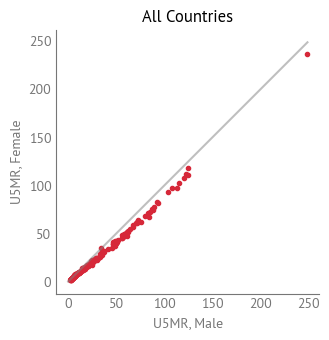

In [50]:
col = 'U5MR'
year = years[-1]
u5mr_gap, u5mr_recent = summarize_gap(u5mr, col)

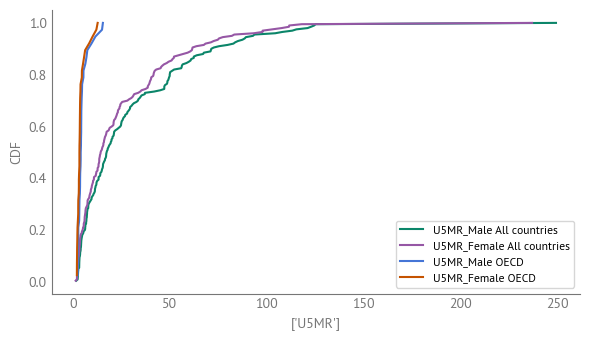

In [51]:
plot_distributions(u5mr_recent)

## Cardiovascular Disease

**Age-standardized cardiovascular disease death rates (per 100,000)** - Deaths from cardiovascular diseases (heart disease, stroke, etc.), age-standardized for cross-country comparison.

**Indicator Code**: Multiple codes tried (WHS2_161, etc.) - see `who_data.py` for implementation details  
**Relevance**: Men typically have higher rates of cardiovascular disease and heart attacks, contributing significantly to the gender gap in mortality. Risk factors include smoking, diet, and potentially biological differences. May capture effects of smoking and other risk factors. Age-standardized rates match HALE methodology.

In [52]:
filename = '../data/who_cardiovascular_death_rates.csv'
cardio, years = load_and_inventory(filename)

(573, 12)
['SA_0000001444']
[nan]
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK' 'PRT' 'PRY'
 'QAT' 'ROU' 'RUS' 'RWA' 'SAU' 'SDN' 'SEN' 'SG

In [53]:
# Rename DeathRate to CardioDeathRate to avoid ambiguity
cardio = cardio.rename(columns={'DeathRate': 'CardioDeathRate'})
cardio.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,CardioDeathRate,DeathRate_Low,DeathRate_High,Comments,DataSource,CountryName
0,SA_0000001444,NaN,AFG,COUNTRY,2004,Both sexes,366.9,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001444,NaN,AFG,COUNTRY,2004,Female,282.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001444,NaN,AFG,COUNTRY,2004,Male,447.4,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001444,NaN,AGO,COUNTRY,2004,Both sexes,142.4,NaN,NaN,NaN,NaN,Angola
4,SA_0000001444,NaN,AGO,COUNTRY,2004,Female,111.0,NaN,NaN,NaN,NaN,Angola


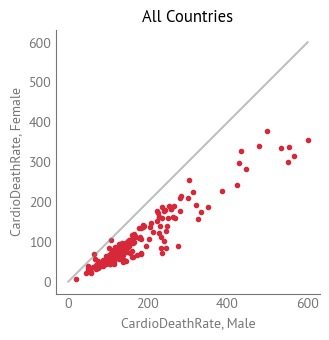

In [54]:
col = 'CardioDeathRate'
year = years[-1]
cardio_gap, cardio_recent = summarize_gap(cardio, col)

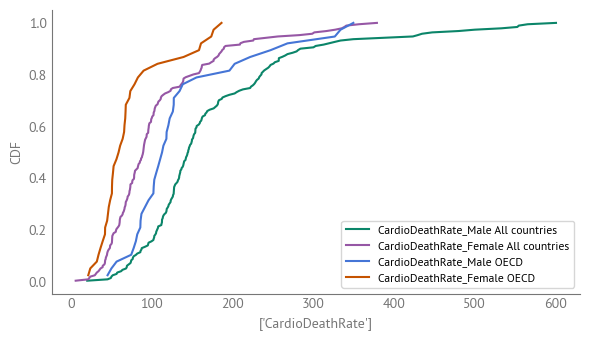

In [55]:
plot_distributions(cardio_recent)

## Diabetes

**Age-standardized death rates, diabetes mellitus (per 100,000)** - Deaths from diabetes, age-standardized for cross-country comparison.

**Indicator Code**: SA_0000001440  
**Relevance**: Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Age-standardized rates match HALE methodology. **Limitation**: Only has data for 2004 (similar to cardiovascular disease indicators), which limits temporal analysis but provides a good cross-sectional snapshot.

In [56]:
filename = '../data/who_diabetes_death_rates.csv'
diabetes, years = load_and_inventory(filename)

(573, 12)
['SA_0000001440']
['Age-standardized death rates, diabetes mellitus, per 100,000']
['Both sexes' 'Female' 'Male']
[nan]
[2004]
['AFG' 'AGO' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI'
 'BEL' 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA'
 'BRB' 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD'
 'COG' 'COK' 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA'
 'FSM' 'GAB' 'GBR' 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM'
 'GUY' 'HND' 'HRV' 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR'
 'ITA' 'JAM' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MCO'
 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNG' 'MOZ' 'MRT'
 'MUS' 'MWI' 'MYS' 'NAM' 'NER' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'NRU'
 'NZL' 'OMN' 'PAK' 'PAN' 'PER' 'PHL' 'PLW' 'PNG' 'POL' 'PRK'

In [57]:
diabetes.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,Comments,DataSource,CountryName
0,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Both sexes,29.3,NaN,NaN,NaN,NaN,Afghanistan
1,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Female,30.9,NaN,NaN,NaN,NaN,Afghanistan
2,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AFG,COUNTRY,2004,Male,27.5,NaN,NaN,NaN,NaN,Afghanistan
3,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Both sexes,67.6,NaN,NaN,NaN,NaN,Angola
4,SA_0000001440,"Age-standardized death rates, diabetes mellitu...",AGO,COUNTRY,2004,Female,74.2,NaN,NaN,NaN,NaN,Angola


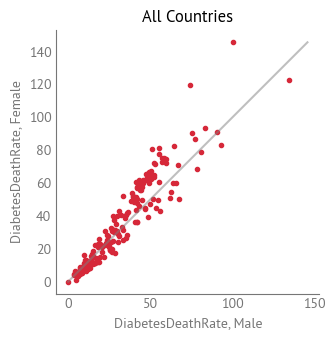

In [58]:
col = 'DiabetesDeathRate'
year = years[-1]
diabetes_gap, diabetes_recent = summarize_gap(diabetes, col)

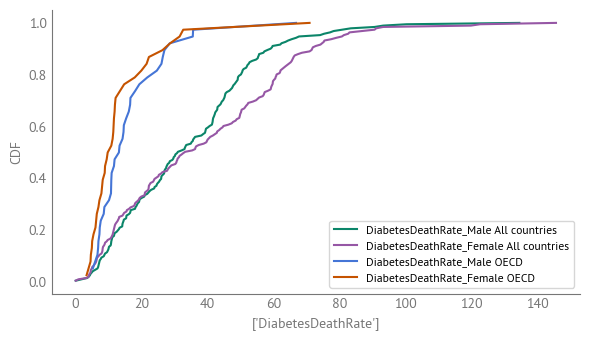

In [59]:
plot_distributions(diabetes_recent)

## NCD Mortality (30-70 years)

**Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease** - Combined non-communicable disease mortality indicator.

**Indicator Code**: NCDMORT3070  
**Relevance**: Combines multiple causes of death (cardiovascular disease, cancer, diabetes, chronic respiratory disease), so it's less specific than individual cause indicators. However, it has much better temporal coverage (2000-2021) than diabetes-specific indicators (which only have 2004 data). This makes it useful for model comparison - trading off specificity for temporal coverage. The combined indicator may capture overall NCD mortality patterns that contribute to the HALE gender gap.

In [60]:
filename = '../data/who_ncd_mortality_30_70.csv'
ncdmort, years = load_and_inventory(filename)

(11100, 12)
['NCDMORT3070']
['Probability (%) of dying between age 30 and exact age 70 from any of cardiovascular disease, cancer, diabetes, or chronic respiratory disease']
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]
['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR' 'BLZ' 'BOL' 'BRA' 'BRB'
 'BRN' 'BTN' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG'
 'COL' 'COM' 'CPV' 'CRI' 'CUB' 'CYP' 'CZE' 'DEU' 'DJI' 'DNK' 'DOM' 'DZA'
 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FRA' 'FSM' 'GAB' 'GBR'
 'GEO' 'GHA' 'GIN' 'GMB' 'GNB' 'GNQ' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JOR'
 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KOR' 'KWT' 'LAO' 'LBN' 'LBR' 'LBY'
 'LCA' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAR' 'MDA' 'MDG' 'MDV' 'MEX' 'MKD'
 'MLI' 'MLT' 'MMR' 'MNE' 'MNG

In [61]:
ncdmort.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,NCDMortality30_70,NCDMortality30_70_Low,NCDMortality30_70_High,Comments,DataSource,CountryName
0,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2000,Both sexes,43.2,25.6,60.0,NaN,NaN,Afghanistan
1,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2001,Both sexes,43.5,25.8,60.3,NaN,NaN,Afghanistan
2,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2002,Both sexes,43.1,25.7,60.2,NaN,NaN,Afghanistan
3,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2003,Both sexes,42.5,25.6,60.1,NaN,NaN,Afghanistan
4,NCDMORT3070,Probability (%) of dying between age 30 and ex...,AFG,COUNTRY,2004,Both sexes,42.3,25.6,60.0,NaN,NaN,Afghanistan


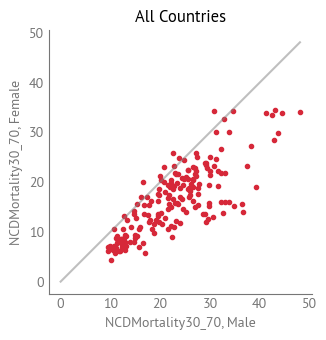

In [62]:
col = 'NCDMortality30_70'
year = years[-1]
ncdmort_gap, ncdmort_recent = summarize_gap(ncdmort, col)

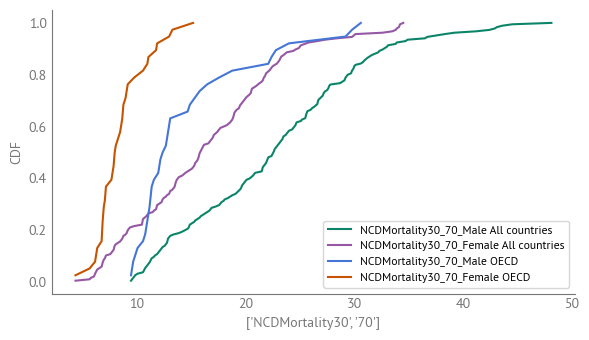

In [63]:
plot_distributions(ncdmort_recent)

## Drug Use Disorders (IHME)

**Drug use disorder death rates (per 100,000 population)** - Deaths from drug use disorders, including overdoses, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Drug overdoses, particularly opioid overdoses, are a major cause of death in some OECD countries (especially the US) and may contribute significantly to the HALE gender gap. This indicator captures overdose deaths that may not be fully captured in the WHO poisoning indicator. Data includes separate male and female values, allowing for gender gap analysis.

In [64]:
def load_ihme_indicator(filename_male, filename_female, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data from separate male and female files and convert to WHO-compatible format.
    
    Converts IHME CSV format (Location=country name, Sex="Male"/"Female") to WHO format
    (Country=country code, Sex="Male"/"Female", etc.). Filters to 2000-2019.
    
    Parameters
    ----------
    filename_male : str
        Path to the IHME CSV file with male data.
    filename_female : str
        Path to the IHME CSV file with female data.
    value_col_name : str
        Name for the value column (e.g., 'DrugDisorderDeathRate', 'DiabetesDeathRate').
    indicator_code : str
        Indicator code for the IHME indicator (e.g., 'IHME_DRUG_DISORDERS', 'IHME_DIABETES_TYPE2').
    indicator_name : str
        Human-readable indicator name (e.g., 'Drug use disorders, death rate per 100,000').
        
    Returns
    -------
    df : pandas.DataFrame
        DataFrame in WHO-compatible format with columns: IndicatorCode, IndicatorName,
        Country, CountryCode, Year, Sex, value_col_name, value_col_name_Low, 
        value_col_name_High, CountryName.
    years : numpy.ndarray
        Array of unique years present in the filtered dataset.
    """
    # Create reverse mapping from country name to code
    who_country_to_code = {country: code for code, country in code_to_who_country.items()}
    
    # Map IHME country names that differ from WHO names
    ihme_country_name_mapping = {
        'Republic of Korea': 'South Korea',
        'United States of America': 'United States'
    }
    
    def process_ihme_file(filename, sex_value):
        """Helper function to process a single IHME file."""
        df = pd.read_csv(filename)
        
        # Filter to 2000-2019 (exclude 2020+ for COVID-19 reasons)
        df = df.query('Year >= 2000 and Year <= 2019')
        
        # Filter to "All ages" (if Age column exists)
        if 'Age' in df.columns:
            df = df.query('Age == "All ages"')
        
        # Map IHME country names to WHO country names
        df['Location'] = df['Location'].replace(ihme_country_name_mapping)
        
        # Convert country names to codes
        df['Country'] = df['Location'].map(who_country_to_code)
        
        # Filter out rows where country mapping failed (not in our country list)
        df = df[df['Country'].notna()].copy()
        
        # Set Sex column to the specified value (Male or Female)
        df['Sex'] = sex_value
        
        # Rename and create columns to match WHO format
        df['IndicatorCode'] = indicator_code
        df['IndicatorName'] = indicator_name
        df['CountryCode'] = 'COUNTRY'
        df[value_col_name] = df['Value']
        df[f'{value_col_name}_Low'] = df['Lower bound']
        df[f'{value_col_name}_High'] = df['Upper bound']
        df['CountryName'] = df['Location']
        
        # Select and reorder columns to match WHO format
        columns_to_keep = [
            'IndicatorCode', 'IndicatorName', 'Country', 'CountryCode', 'Year', 'Sex',
            value_col_name, f'{value_col_name}_Low', f'{value_col_name}_High',
            'CountryName'
        ]
        df = df[columns_to_keep].copy()
        
        return df
    
    # Load and process both files
    df_male = process_ihme_file(filename_male, 'Male')
    df_female = process_ihme_file(filename_female, 'Female')
    
    # Concatenate male and female data
    df = pd.concat([df_male, df_female], ignore_index=True)
    
    # Sort by country, sex, and year
    df = df.sort_values(['Country', 'Sex', 'Year']).reset_index(drop=True)
    
    years = df['Year'].unique()
    
    print(df.shape)
    print(f"Years: {years.min():.0f} - {years.max():.0f}")
    print(f"Countries: {df['Country'].nunique()}")
    print(f"Sex categories: {df['Sex'].unique()}")
    
    return df, years

In [65]:
filename_male = '../data/ihme_drug_disorder_deaths_male.csv'
filename_female = '../data/ihme_drug_disorder_deaths_female.csv'
drug_disorders, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DrugDisorderDeathRate',
    indicator_code='IHME_DRUG_DISORDERS',
    indicator_name='Drug use disorders, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [66]:
drug_disorders.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DrugDisorderDeathRate,DrugDisorderDeathRate_Low,DrugDisorderDeathRate_High,CountryName
0,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2000.0,Female,2.882676,2.484026,3.362499,Australia
1,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2001.0,Female,2.664587,2.285326,3.074588,Australia
2,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2002.0,Female,2.499320,2.146495,2.925388,Australia
3,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2003.0,Female,2.420756,2.069723,2.821397,Australia
4,IHME_DRUG_DISORDERS,"Drug use disorders, death rate per 100,000",AUS,COUNTRY,2004.0,Female,2.357760,2.019524,2.738372,Australia


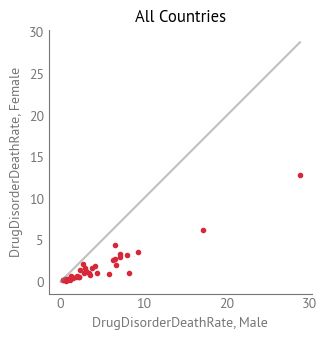

In [67]:
col = 'DrugDisorderDeathRate'
year = years[-1]
drug_disorders_gap, drug_disorders_recent = summarize_gap(drug_disorders, col)

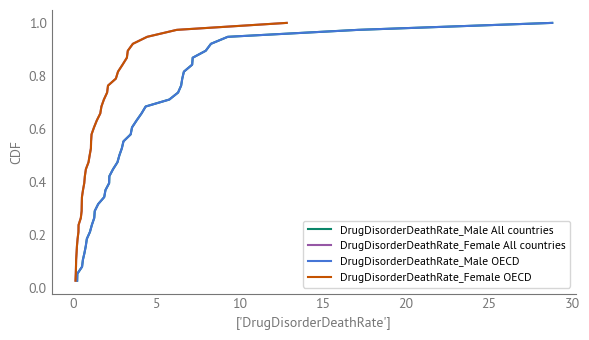

In [68]:
plot_distributions(drug_disorders_recent)

## Diabetes Type 2 (IHME)

**Diabetes type 2 death rates (per 100,000 population)** - Deaths from diabetes mellitus type 2, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: This is an alternative to the WHO diabetes death rate indicator (SA_0000001440) which only has data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Diabetes is a chronic condition that can contribute to the gender gap in mortality, though the relationship may vary by country and healthcare access. Data includes separate male and female values, allowing for gender gap analysis.

In [69]:
filename_male = '../data/ihme_diabetes_deaths_male.csv'
filename_female = '../data/ihme_diabetes_deaths_female.csv'
diabetes_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='DiabetesDeathRate',
    indicator_code='IHME_DIABETES_TYPE2',
    indicator_name='Diabetes mellitus type 2, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [70]:
diabetes_ihme.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,DiabetesDeathRate,DiabetesDeathRate_Low,DiabetesDeathRate_High,CountryName
0,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2000.0,Female,14.248627,12.464444,15.401741,Australia
1,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2001.0,Female,14.344688,12.349151,15.524031,Australia
2,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2002.0,Female,14.975359,12.788477,16.260285,Australia
3,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2003.0,Female,15.525666,13.304746,16.804496,Australia
4,IHME_DIABETES_TYPE2,"Diabetes mellitus type 2, death rate per 100,000",AUS,COUNTRY,2004.0,Female,16.080445,13.757866,17.471747,Australia


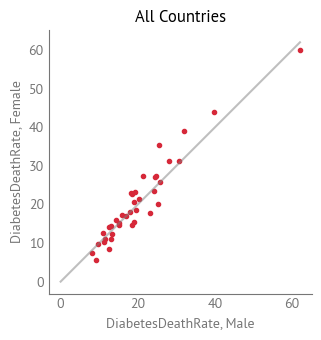

In [71]:
col = 'DiabetesDeathRate'
year = years[-1]
diabetes_ihme_gap, diabetes_ihme_recent = summarize_gap(diabetes_ihme, col)

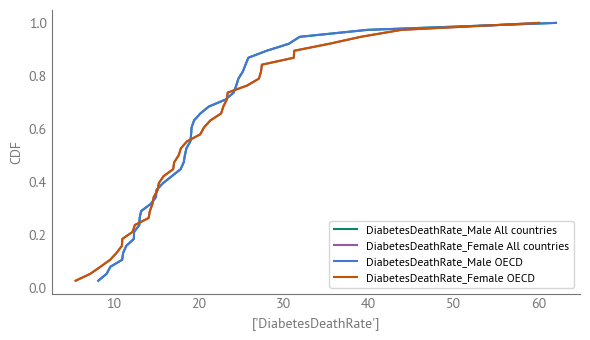

In [72]:
plot_distributions(diabetes_ihme_recent)

## Cardiovascular Diseases (IHME)

**Cardiovascular diseases death rates (per 100,000 population)** - Deaths from cardiovascular diseases, from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Cardiovascular diseases are a major cause of death and may contribute significantly to the HALE gender gap. This is an alternative to the WHO cardiovascular disease death rate indicators which only have data for 2004. IHME data may have better temporal coverage, allowing for more recent data to be used in the analysis. Data includes separate male and female values, allowing for gender gap analysis.

In [73]:
filename_male = '../data/ihme_cardiovascular_deaths_male.csv'
filename_female = '../data/ihme_cardiovascular_deaths_female.csv'
cardiovascular_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='CardioDeathRate',
    indicator_code='IHME_CARDIOVASCULAR',
    indicator_name='Cardiovascular diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [74]:
cardiovascular_ihme.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,CardioDeathRate,CardioDeathRate_Low,CardioDeathRate_High,CountryName
0,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2000.0,Female,259.494605,222.004192,280.150209,Australia
1,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2001.0,Female,253.477767,215.393916,274.406489,Australia
2,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2002.0,Female,253.122588,214.641706,274.256619,Australia
3,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2003.0,Female,244.429433,205.859935,264.521285,Australia
4,IHME_CARDIOVASCULAR,"Cardiovascular diseases, death rate per 100,000",AUS,COUNTRY,2004.0,Female,235.278983,195.651019,255.862336,Australia


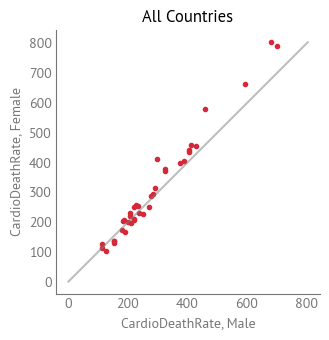

In [75]:
col = 'CardioDeathRate'
year = years[-1]
cardiovascular_ihme_gap, cardiovascular_ihme_recent = summarize_gap(cardiovascular_ihme, col)

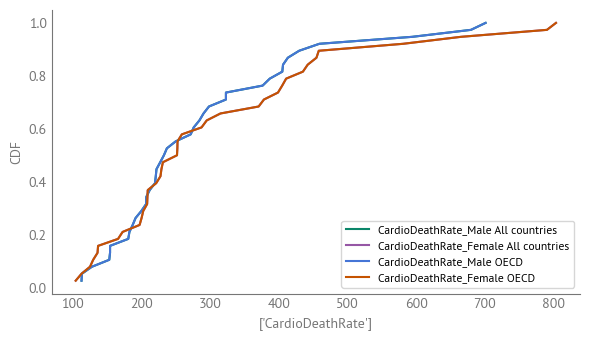

In [76]:
plot_distributions(cardiovascular_ihme_recent)

## Neoplasms (Cancer) (IHME)

**Neoplasms (cancer) death rates (per 100,000 population)** - Deaths from neoplasms (cancer), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Neoplasms (cancer) are a major cause of death and may contribute significantly to the HALE gender gap. Different types of cancer have different gender patterns (e.g., lung cancer is often higher in men, breast cancer is female-specific). This indicator provides comprehensive cancer death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [77]:
filename_male = '../data/ihme_neoplasms_deaths_male.csv'
filename_female = '../data/ihme_neoplasms_deaths_female.csv'
neoplasms_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='NeoplasmsDeathRate',
    indicator_code='IHME_NEOPLASMS',
    indicator_name='Neoplasms (cancer), death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [78]:
neoplasms_ihme.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,NeoplasmsDeathRate,NeoplasmsDeathRate_Low,NeoplasmsDeathRate_High,CountryName
0,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2000.0,Female,174.372594,157.339856,183.123589,Australia
1,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2001.0,Female,176.862341,159.525714,186.065679,Australia
2,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2002.0,Female,179.519671,162.651746,189.101742,Australia
3,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2003.0,Female,178.595845,160.978354,188.735833,Australia
4,IHME_NEOPLASMS,"Neoplasms (cancer), death rate per 100,000",AUS,COUNTRY,2004.0,Female,177.584662,159.143525,187.692801,Australia


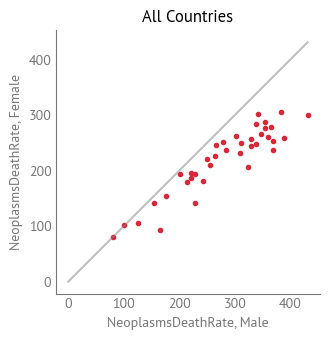

In [79]:
col = 'NeoplasmsDeathRate'
year = years[-1]
neoplasms_ihme_gap, neoplasms_ihme_recent = summarize_gap(neoplasms_ihme, col)

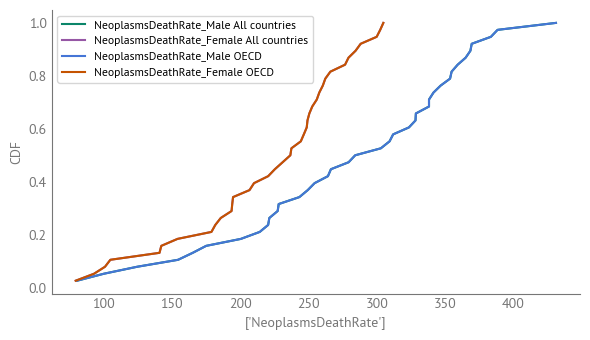

In [80]:
plot_distributions(neoplasms_ihme_recent)

## Chronic Respiratory Diseases (IHME)

**Chronic respiratory diseases death rates (per 100,000 population)** - Deaths from chronic respiratory diseases (including COPD, asthma, and other chronic lung conditions), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Chronic respiratory diseases are a major cause of death and may contribute significantly to the HALE gender gap. These diseases often have gender differences due to factors such as smoking patterns, occupational exposures, and environmental factors. This indicator provides comprehensive chronic respiratory disease death rates with better temporal coverage than WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [81]:
filename_male = '../data/ihme_chronic_respiratory_deaths_male.csv'
filename_female = '../data/ihme_chronic_respiratory_deaths_female.csv'
chronic_respiratory_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='ChronicRespiratoryDeathRate',
    indicator_code='IHME_CHRONIC_RESPIRATORY',
    indicator_name='Chronic respiratory diseases, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [82]:
chronic_respiratory_ihme.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,ChronicRespiratoryDeathRate,ChronicRespiratoryDeathRate_Low,ChronicRespiratoryDeathRate_High,CountryName
0,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2000.0,Female,33.416935,29.058943,36.594912,Australia
1,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2001.0,Female,33.538075,29.034905,36.751005,Australia
2,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2002.0,Female,34.771695,30.095679,38.050192,Australia
3,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2003.0,Female,34.102959,29.234623,37.388706,Australia
4,IHME_CHRONIC_RESPIRATORY,"Chronic respiratory diseases, death rate per 1...",AUS,COUNTRY,2004.0,Female,33.381971,28.496299,37.070731,Australia


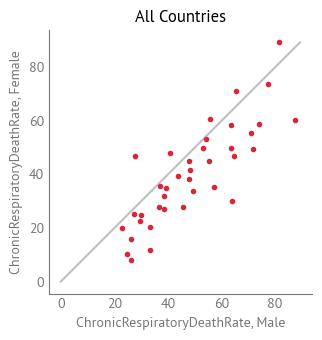

In [83]:
col = 'ChronicRespiratoryDeathRate'
year = years[-1]
chronic_respiratory_ihme_gap, chronic_respiratory_ihme_recent = summarize_gap(chronic_respiratory_ihme, col)

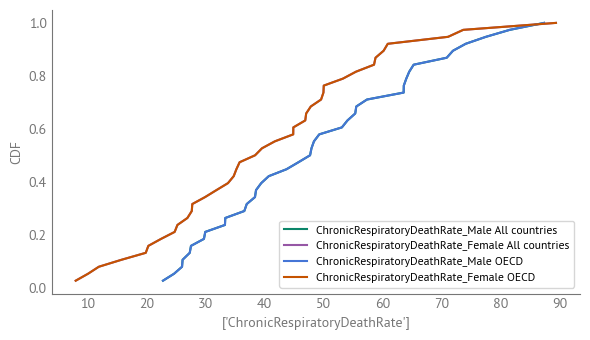

In [84]:
plot_distributions(chronic_respiratory_ihme_recent)

## Unintentional Injuries (IHME)

**Unintentional injuries death rates (per 100,000 population)** - Deaths from unintentional injuries (including falls, drowning, fires, and other accidents), from IHME Global Burden of Disease data.

**Data Source**: IHME Global Burden of Disease (https://vizhub.healthdata.org/gbd-compare/)  
**Relevance**: Unintentional injuries are a significant cause of death and may contribute to the HALE gender gap. These injuries often show gender differences due to occupational exposures, risk-taking behaviors, and activity patterns. This indicator provides comprehensive unintentional injury death rates with better temporal coverage (1990-2023) than many WHO indicators. Data includes separate male and female values, allowing for gender gap analysis.

In [85]:
filename_male = '../data/ihme_unintentional_injuries_deaths_male.csv'
filename_female = '../data/ihme_unintentional_injuries_deaths_female.csv'
unintentional_injuries_ihme, years = load_ihme_indicator(
    filename_male, filename_female,
    value_col_name='UnintentionalInjuriesDeathRate',
    indicator_code='IHME_UNINTENTIONAL_INJURIES',
    indicator_name='Unintentional injuries, death rate per 100,000'
)

(1520, 10)
Years: 2000 - 2019
Countries: 38
Sex categories: ['Female' 'Male']


In [86]:
unintentional_injuries_ihme.head()

,IndicatorCode,IndicatorName,Country,CountryCode,Year,Sex,UnintentionalInjuriesDeathRate,UnintentionalInjuriesDeathRate_Low,UnintentionalInjuriesDeathRate_High,CountryName
0,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2000.0,Female,12.032874,10.437510,13.670943,Australia
1,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2001.0,Female,11.824066,10.182373,13.412276,Australia
2,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2002.0,Female,12.696670,10.897320,14.482235,Australia
3,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2003.0,Female,13.010010,11.096530,14.885208,Australia
4,IHME_UNINTENTIONAL_INJURIES,"Unintentional injuries, death rate per 100,000",AUS,COUNTRY,2004.0,Female,13.977934,11.937847,15.891603,Australia


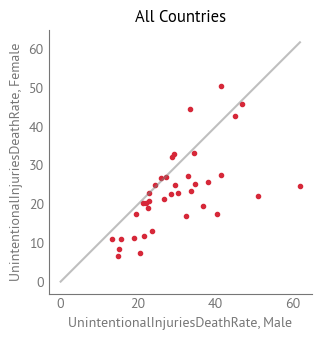

In [87]:
col = 'UnintentionalInjuriesDeathRate'
year = years[-1]
unintentional_injuries_ihme_gap, unintentional_injuries_ihme_recent = summarize_gap(unintentional_injuries_ihme, col)

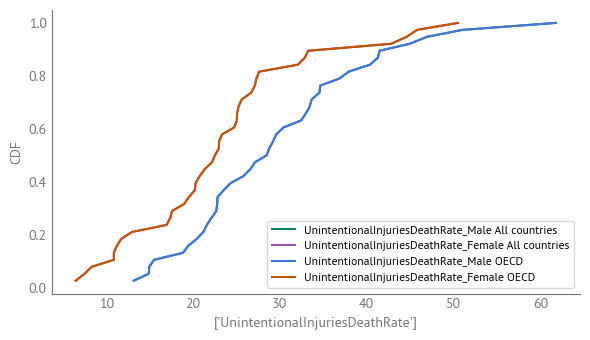

In [88]:
plot_distributions(unintentional_injuries_ihme_recent)

## Phase 1: Data Preparation for Regression Analysis

### Step 1.2: Prepare Target Variable (HALE Gender Gap)

In [89]:
# Calculate HALE gender gap from existing hale_recent DataFrame
hale_recent['HALE_gap'] = hale_recent['HALE_Years_Female'] - hale_recent['HALE_Years_Male']

# Filter to OECD countries
hale_oecd = get_oecd(hale_recent)

# Display summary
hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].describe()

,HALE_Years_Male,HALE_Years_Female,HALE_gap
count,38.000000,38.000000,38.000000
mean,68.627594,70.605057,1.977462
std,2.533251,1.620032,1.601449
min,63.046587,66.927903,0.018589
25%,66.703502,69.990711,0.870341
50%,69.438269,70.730471,1.385737
75%,70.795272,71.462018,2.923884
max,72.085115,75.013962,6.062020


In [90]:
# Diagnostic: Check Israel's (ISR) HALE values
if 'ISR' in hale_recent.index:
    isr_data = hale_recent.loc[['ISR']]
    print("=== Israel (ISR) HALE Data ===")
    print(isr_data[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']])
    if 'CountryName' in isr_data.columns:
        print(f"Country Name: {isr_data['CountryName'].iloc[0]}")
    
    # Check if this is an outlier
    print(f"\nHALE Gap: {isr_data['HALE_gap'].iloc[0]:.2f} years")
    print(f"Male HALE: {isr_data['HALE_Years_Male'].iloc[0]:.2f} years")
    print(f"Female HALE: {isr_data['HALE_Years_Female'].iloc[0]:.2f} years")
    
    # Compare to other countries
    print(f"\nCountries with negative HALE gap (men > women):")
    negative_gap = hale_recent[hale_recent['HALE_gap'] < 0]
    if len(negative_gap) > 0:
        print(negative_gap[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].sort_values('HALE_gap'))
    else:
        print("No other countries with negative gap found")
    
    # Check raw HALE data for Israel to see if there's a data issue
    print(f"\n=== Checking raw HALE data for Israel ===")
    if 'ISR' in hale.index:
        isr_raw = hale[hale['Country'] == 'ISR'].sort_values('Year')
        print(f"Years available: {sorted(isr_raw['Year'].unique())}")
        print(f"\nRaw data by year and sex:")
        print(isr_raw[['Year', 'Sex', 'HALE_Years']].pivot(index='Year', columns='Sex', values='HALE_Years'))
else:
    print("Israel (ISR) not found in hale_recent")

=== Israel (ISR) HALE Data ===
         HALE_Years_Male  HALE_Years_Female  HALE_gap
Country                                              
ISR            71.174433          71.784999  0.610566
Country Name: Israel

HALE Gap: 0.61 years
Male HALE: 71.17 years
Female HALE: 71.78 years

Countries with negative HALE gap (men > women):
         HALE_Years_Male  HALE_Years_Female  HALE_gap
Country                                              
JOR            69.585018          67.324152 -2.260866
QAT            68.367710          66.544907 -1.822802
DZA            67.040830          65.337051 -1.703780
MRT            62.488875          60.821382 -1.667493
BHR            66.301313          64.717522 -1.583791
ARE            70.244253          68.685607 -1.558646
COG            55.296261          54.056384 -1.239877
HTI            55.562416          54.467865 -1.094551
MAR            64.131324          63.043466 -1.087858
LBR            54.536795          53.474988 -1.061807
MLI            54.2

### Step 1.4: Merge All Predictors into Single Dataset

In [91]:
# Start with HALE data as base
analysis_df = hale_oecd[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()

# Merge all predictor DataFrames (already filtered to OECD in earlier sections)
# Note: We will exclude gap columns (_Gap), CountryName, and Year columns before merging
# Gap columns are perfectly collinear with male/female columns
predictor_dfs = {
    #'SmokingPrevalence': get_oecd(smoking_recent),
    'CardioDeathRate': get_oecd(cardiovascular_ihme_recent),
    'ChronicRespiratoryDeathRate': get_oecd(chronic_respiratory_ihme_recent),
    'SuicideRate': get_oecd(suicide_recent),
    'AlcoholDeathRate': get_oecd(alcohol_recent),
    'PoisoningRate': get_oecd(poison_recent),
    'RoadTrafficDeathRate': get_oecd(traffic_recent),
    'HomicideRate': get_oecd(homicide_recent),
    'MaternalMortalityRatio': get_oecd(maternal_recent),
    'U5MR': get_oecd(u5mr_recent),
    'DiabetesDeathRate': get_oecd(diabetes_ihme_recent),
    #'NCDMortality30_70': get_oecd(ncdmort_recent),
    'DrugDisorderDeathRate': get_oecd(drug_disorders_recent),
    'UnintentionalInjuriesDeathRate': get_oecd(unintentional_injuries_ihme_recent),
}

In [92]:
# Summary table of year coverage for each indicator
year_summary_df = summarize_years(predictor_dfs)
year_summary_df

,Indicator,Low_Year,High_Year,Most_Common_Year,N_Countries_Most_Common,Total_Countries
0,CardioDeathRate,2019,2019,2019,38,38
1,ChronicRespiratoryDeathRate,2019,2019,2019,38,38
2,SuicideRate,2019,2019,2019,38,38
3,AlcoholDeathRate,2019,2019,2019,38,38
4,PoisoningRate,2019,2019,2019,38,38
5,RoadTrafficDeathRate,2019,2019,2019,38,38
6,HomicideRate,2019,2019,2019,38,38
7,MaternalMortalityRatio,2019,2019,2019,38,38
8,U5MR,2019,2019,2019,38,38
9,DiabetesDeathRate,2019,2019,2019,38,38


In [93]:

for name, df in predictor_dfs.items():
    drop_cols = ['CountryName', 'Year']
    drop_cols += [col for col in df.columns if col.endswith('_Gap')]
    if drop_cols:
        predictor_dfs[name] = df.drop(columns=drop_cols)

# Check shapes after removing gaps
for name, predictor_df in predictor_dfs.items():
    print(name, predictor_df.shape)

CardioDeathRate (38, 2)
ChronicRespiratoryDeathRate (38, 2)
SuicideRate (38, 2)
AlcoholDeathRate (38, 2)
PoisoningRate (38, 2)
RoadTrafficDeathRate (38, 2)
HomicideRate (38, 2)
MaternalMortalityRatio (38, 1)
U5MR (38, 2)
DiabetesDeathRate (38, 2)
DrugDisorderDeathRate (38, 2)
UnintentionalInjuriesDeathRate (38, 2)


In [94]:
# Merge all predictors on index (Country codes)
for name, df in predictor_dfs.items():
    analysis_df = analysis_df.join(df, how='outer')

# Display shape and column names
analysis_df.shape

(38, 26)

In [95]:
analysis_df.head()

,HALE_Years_Male,HALE_Years_Female,HALE_gap,CardioDeathRate_Male,CardioDeathRate_Female,ChronicRespiratoryDeathRate_Male,ChronicRespiratoryDeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,...,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,DrugDisorderDeathRate_Male,DrugDisorderDeathRate_Female,UnintentionalInjuriesDeathRate_Male,UnintentionalInjuriesDeathRate_Female
Country,,,,,,,,,,,,,,,,,,,,,
AUS,69.678894,70.839417,1.160523,180.669926,172.455631,48.358124,41.738864,19.262646,6.316721,30.074132,...,0.657008,5.293546,4.105110,3.446807,19.050781,15.344569,7.149617,3.276247,22.832344,20.758278
AUT,69.734435,71.097603,1.363167,322.963162,370.647647,47.938666,38.398022,16.571323,4.693402,48.422765,...,0.499875,6.606055,3.796687,3.173931,24.137624,23.436790,3.016784,1.243706,33.001254,27.298444
BEL,69.611904,70.552460,0.940556,227.240941,258.755289,71.882115,49.564510,20.837616,7.684374,40.641776,...,1.134963,4.320729,4.353265,3.482878,12.410137,14.145793,2.388205,1.412564,44.960181,42.816206
CAN,69.657904,70.912614,1.254710,211.889270,197.205802,53.086852,49.964721,16.488952,5.638187,35.024350,...,0.845760,12.266445,5.540480,4.733152,18.403477,14.591645,17.135280,6.223068,27.141988,27.127971
CHE,71.330820,71.668585,0.337766,221.785883,251.684503,38.555188,31.852409,13.921306,5.835274,28.127289,...,0.442086,5.932969,4.364372,3.691953,13.266915,12.252823,4.100939,1.838960,29.227780,32.874999


In [96]:
# Create missing data report
missing_report = pd.DataFrame({
    'Indicator': analysis_df.columns,
    'Missing_Count': [analysis_df[col].isna().sum() for col in analysis_df.columns],
    'Missing_Pct': [analysis_df[col].isna().sum() / len(analysis_df) * 100 for col in analysis_df.columns],
    'Available_Count': [analysis_df[col].notna().sum() for col in analysis_df.columns]
}).sort_values('Missing_Count', ascending=False)

missing_report

,Indicator,Missing_Count,Missing_Pct,Available_Count
0,HALE_Years_Male,0,0.0,38
1,HALE_Years_Female,0,0.0,38
24,UnintentionalInjuriesDeathRate_Male,0,0.0,38
23,DrugDisorderDeathRate_Female,0,0.0,38
22,DrugDisorderDeathRate_Male,0,0.0,38
21,DiabetesDeathRate_Female,0,0.0,38
20,DiabetesDeathRate_Male,0,0.0,38
19,U5MR_Female,0,0.0,38
18,U5MR_Male,0,0.0,38
17,MaternalMortalityRatio_Female,0,0.0,38


In [97]:
# Show which countries have complete data for all indicators
complete_cases = analysis_df.dropna()
complete_cases.shape[0], f"{complete_cases.shape[0] / len(analysis_df) * 100:.1f}% of countries have complete data"

(38, '100.0% of countries have complete data')

In [98]:
#bad = analysis_df['IPVPrevalence_Female'].isna()
#analysis_df.loc[bad].index.map(code_to_who_country)

### Step 1.5: Create Final Analysis Dataset

In [99]:
# Use complete-case analysis for primary model
analysis_complete = analysis_df.dropna()

# Document excluded countries
excluded_countries = set(analysis_df.index) - set(analysis_complete.index)
excluded_countries if excluded_countries else "No countries excluded - all OECD countries have complete data"

'No countries excluded - all OECD countries have complete data'

In [100]:
# Separate target and predictors
target = analysis_complete['HALE_gap']
predictors = analysis_complete.drop(columns=['HALE_gap', 'HALE_Years_Male', 'HALE_Years_Female'])

# Display final dataset info
pd.DataFrame({
    'Dataset': ['Complete Cases'],
    'Countries': [len(analysis_complete)],
    'Target_Variable': ['HALE_gap'],
    'Number_of_Predictors': [len(predictors.columns)],
    'Predictor_Names': [', '.join(predictors.columns)]
})

,Dataset,Countries,Target_Variable,Number_of_Predictors,Predictor_Names
0,Complete Cases,38,HALE_gap,23,"CardioDeathRate_Male, CardioDeathRate_Female, ..."


In [101]:
# Summary of Phase 1 completion
pd.DataFrame({
    'Step': ['1.2: Target Variable', '1.4: Merge', '1.5: Complete Cases'],
    'Status': ['Complete', 'Complete', 'Complete'],
    'Countries': [len(hale_oecd), len(analysis_df), len(analysis_complete)],
    'Variables': [3, len(analysis_df.columns), len(analysis_complete.columns)]
})

,Step,Status,Countries,Variables
0,1.2: Target Variable,Complete,38,3
1,1.4: Merge,Complete,38,26
2,1.5: Complete Cases,Complete,38,26


**Note**: Predictor standardization will be done as part of the regression pipeline (e.g., using `StandardScaler` in scikit-learn's pipeline), not as a separate preprocessing step.

## Phase 2: Exploratory Data Analysis

### Step 2.1: Descriptive Statistics

In [102]:
target.sort_values()

Country
NLD    0.018589
SWE    0.134025
ISL    0.160198
NOR    0.238734
CHE    0.337766
IRL    0.454396
NZL    0.486508
ISR    0.610566
GBR    0.694553
DEU    0.862288
DNK    0.894501
LUX    0.914529
BEL    0.940556
ITA    1.071289
AUS    1.160523
TUR    1.169973
CAN    1.254710
GRC    1.325006
AUT    1.363167
CHL    1.408306
ESP    1.523123
USA    1.800777
FRA    1.817945
FIN    2.243172
CRI    2.258242
PRT    2.391484
COL    2.892291
SVN    2.908994
JPN    2.928847
CZE    3.091037
MEX    3.095419
KOR    3.564595
HUN    3.722175
SVK    3.930964
EST    4.790534
POL    4.929800
LVA    5.691968
LTU    6.062020
Name: HALE_gap, dtype: float64

In [103]:
# Summary statistics for target variable (HALE gap)
target.describe()

count    38.000000
mean      1.977462
std       1.601449
min       0.018589
25%       0.870341
50%       1.385737
75%       2.923884
max       6.062020
Name: HALE_gap, dtype: float64

In [104]:
# Summary statistics for all predictors
predictors.describe()

,CardioDeathRate_Male,CardioDeathRate_Female,ChronicRespiratoryDeathRate_Male,ChronicRespiratoryDeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,AlcoholDeathRate_Female,PoisoningRate_Male,PoisoningRate_Female,...,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,DrugDisorderDeathRate_Male,DrugDisorderDeathRate_Female,UnintentionalInjuriesDeathRate_Male,UnintentionalInjuriesDeathRate_Female
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,287.082382,308.540284,48.772263,40.108183,15.683649,4.778025,51.670267,13.524238,0.516938,0.199204,...,1.220929,10.386346,5.040331,4.226633,19.975597,20.625066,4.438386,1.720787,29.711353,23.255669
std,143.881874,175.710878,17.638881,18.427862,6.373638,2.315249,39.794802,17.253014,0.520076,0.137967,...,1.449328,12.246133,3.111852,2.591025,9.876602,10.941155,5.296979,2.305292,10.754456,10.464067
min,112.593316,104.093161,22.799842,8.029024,5.462428,1.428371,12.860832,2.859710,0.001308,0.000505,...,0.183065,1.587783,2.537916,2.133197,8.233362,5.576414,0.229264,0.130321,13.183687,6.490970
25%,193.454241,200.696524,34.154103,27.123633,11.922116,3.150607,29.301366,6.499013,0.250998,0.106487,...,0.500611,4.289471,3.385258,2.828963,13.132826,14.181995,1.265356,0.462507,22.261761,17.432826
50%,234.795613,251.956146,47.819922,38.977976,15.574885,4.795838,40.036996,8.540945,0.375002,0.181245,...,0.737735,5.971343,4.172973,3.466179,18.493674,17.806305,2.844936,1.020506,28.634186,22.756358
75%,363.093991,403.427613,63.559091,50.005219,19.233786,5.906438,51.733670,11.797030,0.560288,0.256098,...,1.085750,11.973693,4.821946,4.011590,24.361875,25.132618,6.440109,2.072681,34.636400,27.024826
max,701.266757,803.819385,87.311001,89.323806,37.016864,13.210332,187.011110,80.287815,2.836687,0.640002,...,6.926356,66.191870,15.548194,12.848685,61.994963,59.991715,28.815723,12.839003,61.810688,50.533293


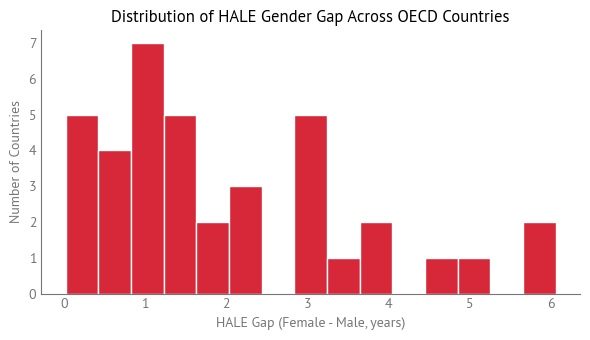

In [105]:
# Distribution of HALE gap across OECD countries
plt.hist(target, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white')
decorate(xlabel='HALE Gap (Female - Male, years)', 
         ylabel='Number of Countries',
         title='Distribution of HALE Gender Gap Across OECD Countries')

In [106]:
# Identify potential outliers using IQR method
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target[(target < lower_bound) | (target > upper_bound)]
outliers_df = pd.DataFrame({
    'Country': outliers.index,
    'HALE_Gap': outliers.values
}).sort_values('HALE_Gap')

outliers_df if not outliers_df.empty else "No outliers detected using IQR method"

,Country,HALE_Gap
0,LTU,6.06202


### Step 2.2: Correlation Analysis

In [107]:
# Calculate correlation matrix of all predictors
correlation_matrix = predictors.corr()

# Display correlation matrix
correlation_matrix

,CardioDeathRate_Male,CardioDeathRate_Female,ChronicRespiratoryDeathRate_Male,ChronicRespiratoryDeathRate_Female,SuicideRate_Male,SuicideRate_Female,AlcoholDeathRate_Male,AlcoholDeathRate_Female,PoisoningRate_Male,PoisoningRate_Female,...,HomicideRate_Female,MaternalMortalityRatio_Female,U5MR_Male,U5MR_Female,DiabetesDeathRate_Male,DiabetesDeathRate_Female,DrugDisorderDeathRate_Male,DrugDisorderDeathRate_Female,UnintentionalInjuriesDeathRate_Male,UnintentionalInjuriesDeathRate_Female
CardioDeathRate_Male,1.000000,0.988877,-0.037433,-0.293032,0.475346,-0.037042,0.825066,0.777965,0.669420,0.597769,...,-0.030548,-0.127806,-0.260236,-0.263575,0.162386,0.272569,0.008555,-0.125009,0.739232,0.159331
CardioDeathRate_Female,0.988877,1.000000,-0.077620,-0.342495,0.496613,-0.007464,0.841486,0.790642,0.646736,0.548660,...,-0.056661,-0.155556,-0.307156,-0.311427,0.147513,0.271513,-0.032014,-0.171055,0.773432,0.223258
ChronicRespiratoryDeathRate_Male,-0.037433,-0.077620,1.000000,0.832161,-0.265241,-0.020787,-0.343636,-0.304063,-0.241320,0.109037,...,-0.276971,-0.186741,-0.179614,-0.180990,-0.036910,-0.067299,0.182318,0.213798,-0.097498,0.256963
ChronicRespiratoryDeathRate_Female,-0.293032,-0.342495,0.832161,1.000000,-0.341260,0.017016,-0.505924,-0.454620,-0.373920,-0.086375,...,-0.235503,-0.145131,-0.126297,-0.130383,-0.089809,-0.210590,0.389619,0.463668,-0.364406,0.159326
SuicideRate_Male,0.475346,0.496613,-0.265241,-0.341260,1.000000,0.700049,0.669639,0.656356,0.612751,0.460491,...,-0.063669,-0.218241,-0.354817,-0.361511,-0.132767,-0.123423,0.201415,0.143102,0.666436,0.235886
SuicideRate_Female,-0.037042,-0.007464,-0.020787,0.017016,0.700049,1.000000,0.067644,0.114657,0.001777,-0.011961,...,-0.254429,-0.304536,-0.446621,-0.453961,-0.331058,-0.379980,0.181888,0.207745,0.289100,0.332861
AlcoholDeathRate_Male,0.825066,0.841486,-0.343636,-0.505924,0.669639,0.067644,1.000000,0.946049,0.770091,0.552167,...,0.216826,0.062323,-0.086485,-0.095010,0.202701,0.307912,0.016064,-0.127119,0.722684,0.036890
AlcoholDeathRate_Female,0.777965,0.790642,-0.304063,-0.454620,0.656356,0.114657,0.946049,1.000000,0.740877,0.489470,...,0.184035,0.032096,-0.139978,-0.142291,0.067156,0.177951,0.088372,-0.065968,0.692520,0.030110
PoisoningRate_Male,0.669420,0.646736,-0.241320,-0.373920,0.612751,0.001777,0.770091,0.740877,1.000000,0.802916,...,0.157160,-0.043889,-0.028139,-0.030212,0.129052,0.177072,0.095933,-0.011876,0.536372,-0.123344
PoisoningRate_Female,0.597769,0.548660,0.109037,-0.086375,0.460491,-0.011961,0.552167,0.489470,0.802916,1.000000,...,0.155014,-0.009561,0.055800,0.050930,0.224352,0.265323,0.118516,0.078447,0.506637,0.012802


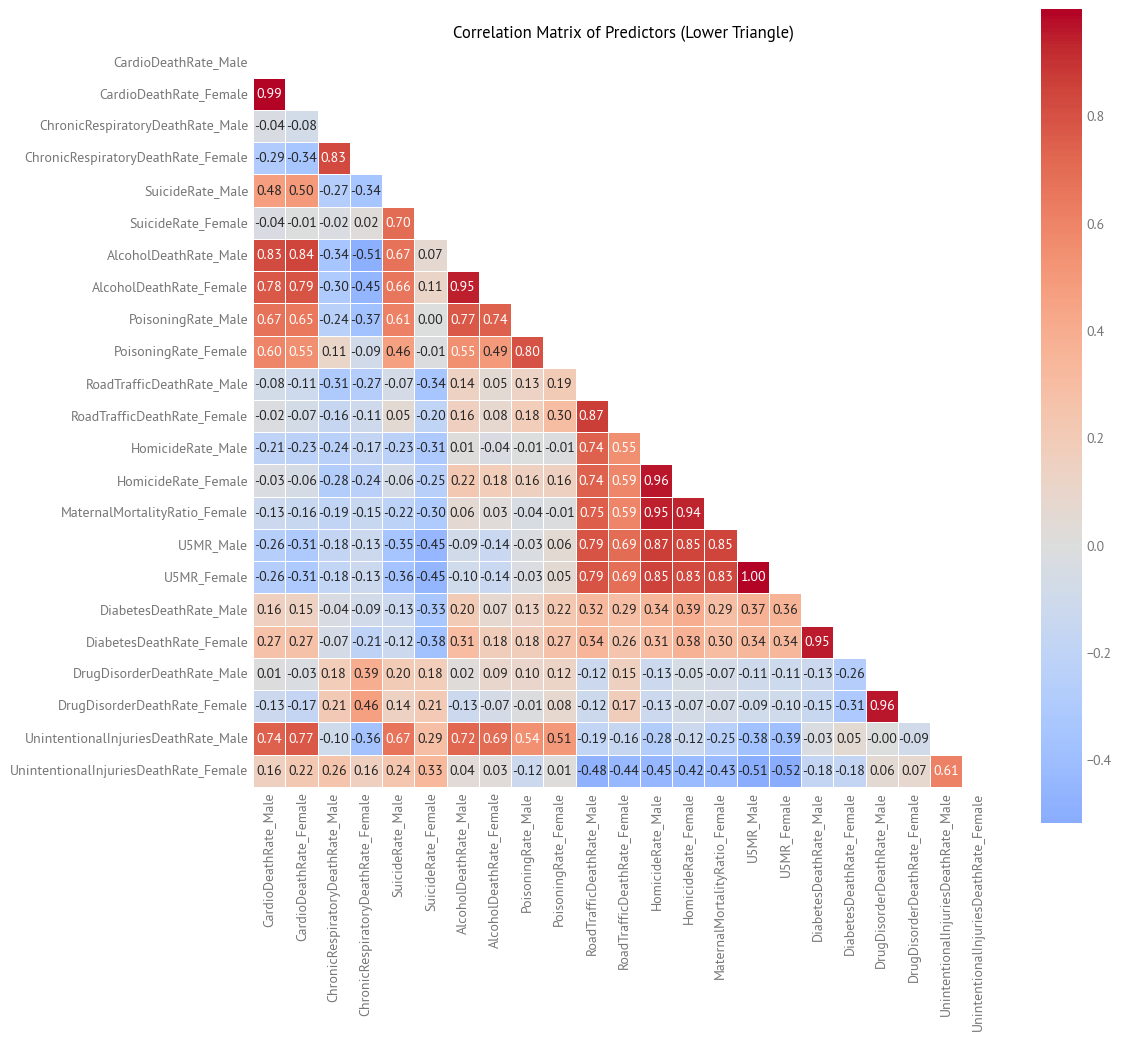

In [108]:
# Visualize correlation matrix as heatmap
import seaborn as sns

plt.figure(figsize=(12, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
decorate(title='Correlation Matrix of Predictors (Lower Triangle)')

In [109]:
# Identify highly correlated predictor pairs (|correlation| > 0.7)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append({
                'Predictor_1': correlation_matrix.columns[i],
                'Predictor_2': correlation_matrix.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
high_corr_df if not high_corr_df.empty else "No highly correlated pairs (|r| > 0.7) found"

,Predictor_1,Predictor_2,Correlation
29,U5MR_Male,U5MR_Female,0.998492
0,CardioDeathRate_Male,CardioDeathRate_Female,0.988877
31,DrugDisorderDeathRate_Male,DrugDisorderDeathRate_Female,0.959092
20,HomicideRate_Male,HomicideRate_Female,0.959071
30,DiabetesDeathRate_Male,DiabetesDeathRate_Female,0.954586
21,HomicideRate_Male,MaternalMortalityRatio_Female,0.950210
9,AlcoholDeathRate_Male,AlcoholDeathRate_Female,0.946049
24,HomicideRate_Female,MaternalMortalityRatio_Female,0.937440
22,HomicideRate_Male,U5MR_Male,0.869030
14,RoadTrafficDeathRate_Male,RoadTrafficDeathRate_Female,0.865403


In [110]:
# Summary of correlation analysis
pd.DataFrame({
    'Analysis': ['Total Predictors', 'High Correlations (|r| > 0.7)', 'Max Correlation', 'Min Correlation'],
    'Value': [
        len(predictors.columns),
        len(high_corr_pairs) if high_corr_pairs else 0,
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].max(),
        correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)].min()
    ]
})

,Analysis,Value
0,Total Predictors,23.000000
1,High Correlations (|r| > 0.7),32.000000
2,Max Correlation,0.998492
3,Min Correlation,-0.518252


### Step 2.3: Extreme Values and Country Rankings

#### For Each Indicator: Highest and Lowest Values

In [111]:
# Get list of indicators from predictor_dfs
indicator_names = list(predictor_dfs.keys())

# Create tables for each indicator showing top 5 and bottom 5 countries
indicator_extremes = {}

for indicator_name in indicator_names:
    # Get the recent dataframe for this indicator
    # We need to find which recent dataframe corresponds to this indicator
    # Check if it's in the predictor_dfs (which uses get_oecd on recent dataframes)
    df_recent = predictor_dfs[indicator_name]
    
    # Get male and female column names
    male_col = f'{indicator_name}_Male'
    female_col = f'{indicator_name}_Female'
    
    if male_col in df_recent.columns and female_col in df_recent.columns:
        # Create summary for this indicator
        indicator_data = df_recent[[male_col, female_col]].copy()
        if 'CountryName' in df_recent.columns:
            indicator_data['CountryName'] = df_recent['CountryName']
        else:
            # Map country codes to names
            indicator_data['CountryName'] = indicator_data.index.map(code_to_who_country)
        
        # For male values
        male_sorted = indicator_data.sort_values(male_col, ascending=False)
        male_top5 = male_sorted.head(5)[['CountryName', male_col]].copy()
        male_top5['Rank'] = range(1, 6)
        male_bottom5 = male_sorted.tail(5)[['CountryName', male_col]].copy()
        male_bottom5['Rank'] = range(len(male_sorted)-4, len(male_sorted)+1)
        
        # For female values
        female_sorted = indicator_data.sort_values(female_col, ascending=False)
        female_top5 = female_sorted.head(5)[['CountryName', female_col]].copy()
        female_top5['Rank'] = range(1, 6)
        female_bottom5 = female_sorted.tail(5)[['CountryName', female_col]].copy()
        female_bottom5['Rank'] = range(len(female_sorted)-4, len(female_sorted)+1)
        
        indicator_extremes[indicator_name] = {
            'male_top5': male_top5,
            'male_bottom5': male_bottom5,
            'female_top5': female_top5,
            'female_bottom5': female_bottom5
        }

# Display results for a few key indicators
key_indicators = ['AlcoholDeathRate', 'HomicideRate', 'CardioDeathRate', 'SuicideRate']
for indicator in key_indicators:
    if indicator in indicator_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Extreme Values")
        print(f"{'='*60}")
        print(f"\nTop 5 Countries - Male Values:")
        print(indicator_extremes[indicator]['male_top5'].to_string(index=False))
        print(f"\nBottom 5 Countries - Male Values:")
        print(indicator_extremes[indicator]['male_bottom5'].to_string(index=False))
        print(f"\nTop 5 Countries - Female Values:")
        print(indicator_extremes[indicator]['female_top5'].to_string(index=False))
        print(f"\nBottom 5 Countries - Female Values:")
        print(indicator_extremes[indicator]['female_bottom5'].to_string(index=False))


AlcoholDeathRate - Extreme Values

Top 5 Countries - Male Values:
CountryName  AlcoholDeathRate_Male  Rank
     Latvia             187.011110     1
  Lithuania             186.286009     2
    Estonia             131.643803     3
     Poland              87.466395     4
   Slovakia              85.223150     5

Bottom 5 Countries - Male Values:
CountryName  AlcoholDeathRate_Male  Rank
     Greece              26.920608    34
     Norway              23.689685    35
      Italy              23.253117    36
    Türkiye              14.360021    37
     Israel              12.860832    38

Top 5 Countries - Female Values:
CountryName  AlcoholDeathRate_Female  Rank
  Lithuania                80.287815     1
     Latvia                78.467593     2
    Estonia                47.508003     3
    Hungary                15.694017     4
     Poland                15.100563     5

Bottom 5 Countries - Female Values:
CountryName  AlcoholDeathRate_Female  Rank
     Norway                 5.3813

#### For Gender Gaps: Largest and Smallest Gaps

In [112]:
# Create a mapping from indicator names to their recent dataframes and value column names
# This maps the predictor_dfs keys to the actual _recent dataframes and their value columns
indicator_to_recent = {
    'CardioDeathRate': ('cardiovascular_ihme_recent', 'CardioDeathRate'),
    'ChronicRespiratoryDeathRate': ('chronic_respiratory_ihme_recent', 'ChronicRespiratoryDeathRate'),
    'SuicideRate': ('suicide_recent', 'SuicideRate'),
    'AlcoholDeathRate': ('alcohol_recent', 'AlcoholDeathRate'),
    'PoisoningRate': ('poison_recent', 'PoisoningRate'),
    'RoadTrafficDeathRate': ('traffic_recent', 'RoadTrafficDeathRate'),
    'HomicideRate': ('homicide_recent', 'HomicideRate'),
    'U5MR': ('u5mr_recent', 'U5MR'),
    'DiabetesDeathRate': ('diabetes_ihme_recent', 'DiabetesDeathRate'),
    'DrugDisorderDeathRate': ('drug_disorders_recent', 'DrugDisorderDeathRate'),
    'UnintentionalInjuriesDeathRate': ('unintentional_injuries_ihme_recent', 'UnintentionalInjuriesDeathRate'),
}

gap_extremes = {}

for indicator_name in indicator_names:
    if indicator_name in indicator_to_recent:
        recent_var_name, value_col = indicator_to_recent[indicator_name]
        
        # Get the recent dataframe (already filtered to OECD and most recent year)
        if recent_var_name in globals():
            df_recent = globals()[recent_var_name]
            
            # Get column names
            male_col = f'{value_col}_Male'
            female_col = f'{value_col}_Female'
            gap_col = f'{value_col}_Gap'
            
            if gap_col in df_recent.columns:
                # Create summary with country names
                gap_data = df_recent[[male_col, female_col, gap_col]].copy()
                if 'CountryName' in df_recent.columns:
                    gap_data['CountryName'] = df_recent['CountryName']
                else:
                    gap_data['CountryName'] = df_recent.index.map(code_to_who_country)
                
                # Sort by gap (largest positive gaps first)
                # Note: Gap is computed as Female - Male, so positive means females have higher rates
                gap_sorted = gap_data.sort_values(gap_col, ascending=False)
                
                gap_top5 = gap_sorted.head(5).copy()
                gap_top5['Rank'] = range(1, 6)
                gap_bottom5 = gap_sorted.tail(5).copy()
                gap_bottom5['Rank'] = range(len(gap_sorted)-4, len(gap_sorted)+1)
                
                gap_extremes[indicator_name] = {
                    'top5': gap_top5,
                    'bottom5': gap_bottom5
                }

# Display results for key indicators
for indicator in key_indicators:
    if indicator in gap_extremes:
        print(f"\n{'='*60}")
        print(f"{indicator} - Gender Gap Extremes (Female - Male)")
        print(f"{'='*60}")
        gap_info = gap_extremes[indicator]
        print(f"\nTop 5 Countries - Largest Gaps (Female > Male):")
        cols_to_show = ['CountryName', 'Rank', f'{indicator_to_recent[indicator][1]}_Male', 
                       f'{indicator_to_recent[indicator][1]}_Female', f'{indicator_to_recent[indicator][1]}_Gap']
        print(gap_info['top5'][cols_to_show].to_string(index=False))
        print(f"\nBottom 5 Countries - Smallest Gaps (Male > Female):")
        print(gap_info['bottom5'][cols_to_show].to_string(index=False))


AlcoholDeathRate - Gender Gap Extremes (Female - Male)

Top 5 Countries - Largest Gaps (Female > Male):
CountryName  Rank  AlcoholDeathRate_Male  AlcoholDeathRate_Female  AlcoholDeathRate_Gap
      Qatar     1               9.294819                10.939859              1.645041
       Oman     2               9.524310                 9.713388              0.189078
     Kuwait     3               1.503209                 0.246004             -1.257205
      Syria     4               4.870535                 3.364934             -1.505602
      Sudan     5               8.445132                 6.604666             -1.840466

Bottom 5 Countries - Smallest Gaps (Male > Female):
CountryName  Rank  AlcoholDeathRate_Male  AlcoholDeathRate_Female  AlcoholDeathRate_Gap
      Gabon   176             159.548098                28.488985           -131.059113
   Mongolia   177             196.230983                59.954963           -136.276020
    Belarus   178             246.642196          

#### For HALE Gap: All Countries Ranked

In [113]:
# Create ranked table of all countries by HALE gap
hale_ranked = analysis_complete[['HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].copy()
hale_ranked['CountryName'] = hale_ranked.index.map(code_to_who_country)
hale_ranked = hale_ranked.sort_values('HALE_gap', ascending=False).reset_index()
hale_ranked['Rank'] = range(1, len(hale_ranked) + 1)

# Reorder columns
hale_ranked = hale_ranked[['Rank', 'Country', 'CountryName', 'HALE_Years_Male', 
                           'HALE_Years_Female', 'HALE_gap']]

print("All Countries Ranked by HALE Gap (Female - Male)")
print("="*80)
print(hale_ranked.to_string(index=False))

All Countries Ranked by HALE Gap (Female - Male)
 Rank Country    CountryName  HALE_Years_Male  HALE_Years_Female  HALE_gap
    1     LTU      Lithuania        63.104683          69.166703  6.062020
    2     LVA         Latvia        63.046587          68.738555  5.691968
    3     POL         Poland        65.084376          70.014177  4.929800
    4     EST        Estonia        65.801117          70.591652  4.790534
    5     SVK       Slovakia        65.475856          69.406819  3.930964
    6     HUN        Hungary        64.668835          68.391010  3.722175
    7     KOR    South Korea        70.624330          74.188925  3.564595
    8     MEX         Mexico        63.922174          67.017593  3.095419
    9     CZE        Czechia        66.923801          70.014838  3.091037
   10     JPN          Japan        72.085115          75.013962  2.928847
   11     SVN       Slovenia        68.776654          71.685649  2.908994
   12     COL       Colombia        66.443459      

In [114]:
# Summary statistics for HALE gap
print("\nHALE Gap Summary Statistics:")
print("="*50)
print(f"Mean HALE Gap: {hale_ranked['HALE_gap'].mean():.2f} years")
print(f"Median HALE Gap: {hale_ranked['HALE_gap'].median():.2f} years")
print(f"Standard Deviation: {hale_ranked['HALE_gap'].std():.2f} years")
print(f"Range: {hale_ranked['HALE_gap'].min():.2f} to {hale_ranked['HALE_gap'].max():.2f} years")
print(f"\nCountries with Largest HALE Gap (Top 5):")
print(hale_ranked.head(5)[['Rank', 'CountryName', 'HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].to_string(index=False))
print(f"\nCountries with Smallest HALE Gap (Bottom 5):")
print(hale_ranked.tail(5)[['Rank', 'CountryName', 'HALE_Years_Male', 'HALE_Years_Female', 'HALE_gap']].to_string(index=False))


HALE Gap Summary Statistics:
Mean HALE Gap: 1.98 years
Median HALE Gap: 1.39 years
Standard Deviation: 1.60 years
Range: 0.02 to 6.06 years

Countries with Largest HALE Gap (Top 5):
 Rank CountryName  HALE_Years_Male  HALE_Years_Female  HALE_gap
    1   Lithuania        63.104683          69.166703  6.062020
    2      Latvia        63.046587          68.738555  5.691968
    3      Poland        65.084376          70.014177  4.929800
    4     Estonia        65.801117          70.591652  4.790534
    5    Slovakia        65.475856          69.406819  3.930964

Countries with Smallest HALE Gap (Bottom 5):
 Rank CountryName  HALE_Years_Male  HALE_Years_Female  HALE_gap
   34 Switzerland        71.330820          71.668585  0.337766
   35      Norway        71.042668          71.281402  0.238734
   36     Iceland        71.302050          71.462248  0.160198
   37      Sweden        71.327303          71.461329  0.134025
   38 Netherlands        71.052035          71.070623  0.018589


### Step 2.4: Save Data for Future Use

In [115]:
# Save predictors and target to HDF5 file for future use
import pandas as pd

# Create a dictionary with all the data we want to save
data_to_save = {
    'predictors': predictors,
    'target': target,
    'analysis_complete': analysis_complete,
    'hale_ranked': hale_ranked
}

# Save to HDF5 file
hdf_file = '../data/hale_analysis_data.h5'
with pd.HDFStore(hdf_file, mode='w') as store:
    store['predictors'] = predictors
    store['target'] = target

### Step 2.5: Load Saved Data

In [116]:
# Code to read the saved data back from HDF5 file
hdf_file = '../data/hale_analysis_data.h5'

# Read data back
with pd.HDFStore(hdf_file, mode='r') as store:
    predictors_loaded = store['predictors']
    target_loaded = store['target']

### Step 2.6: Statsmodels Linear Regression (Non-Negligible Indicators Only)

In [117]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

# Define indicators with non-negligible importance (total importance > 1.0)
# Based on coefficient-based importance results
non_negligible_indicators = [
    'AlcoholDeathRate',           # 77.60
    'CardioDeathRate',             # 26.92
    'ChronicRespiratoryDeathRate', # 22.79
    'UnintentionalInjuriesDeathRate', # 3.10
    'SuicideRate',                 # 2.12
    'MaternalMortalityRatio',      # 1.29 (female-only)
    'RoadTrafficDeathRate',        # 1.00
]

# Select predictors for non-negligible indicators
# Include both male and female columns for each indicator (except maternal mortality)
selected_predictors = []
for indicator in non_negligible_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    if indicator == 'MaternalMortalityRatio':
        # Maternal mortality is female-only
        if female_col in predictors.columns:
            selected_predictors.append(female_col)
    else:
        # Include both male and female
        if male_col in predictors.columns:
            selected_predictors.append(male_col)
        if female_col in predictors.columns:
            selected_predictors.append(female_col)

# Create subset of predictors with only non-negligible indicators
X_selected = predictors[selected_predictors].copy()

print(f"Selected {len(selected_predictors)} predictors from {len(non_negligible_indicators)} indicators")
print(f"Predictors: {selected_predictors}")
print(f"\nData shape: {X_selected.shape}")

Selected 13 predictors from 7 indicators
Predictors: ['AlcoholDeathRate_Male', 'AlcoholDeathRate_Female', 'CardioDeathRate_Male', 'CardioDeathRate_Female', 'ChronicRespiratoryDeathRate_Male', 'ChronicRespiratoryDeathRate_Female', 'UnintentionalInjuriesDeathRate_Male', 'UnintentionalInjuriesDeathRate_Female', 'SuicideRate_Male', 'SuicideRate_Female', 'MaternalMortalityRatio_Female', 'RoadTrafficDeathRate_Male', 'RoadTrafficDeathRate_Female']

Data shape: (38, 13)


In [118]:
# Add constant term for intercept (statsmodels doesn't add it by default)
X_with_const = sm.add_constant(X_selected)

# Fit OLS regression model
ols_model = OLS(target, X_with_const).fit()

# Display summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               HALE_gap   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     35.18
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           1.98e-12
Time:                        10:10:14   Log-Likelihood:                -14.336
No. Observations:                  38   AIC:                             56.67
Df Residuals:                      24   BIC:                             79.60
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [119]:
# Extract key statistics
print("\n" + "="*60)
print("Model Summary Statistics")
print("="*60)
print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"F-statistic: {ols_model.fvalue:.4f}")
print(f"F-statistic p-value: {ols_model.f_pvalue:.4e}")
print(f"Number of observations: {ols_model.nobs}")
print(f"Number of predictors: {len(selected_predictors)}")
print(f"\nAIC: {ols_model.aic:.2f}")
print(f"BIC: {ols_model.bic:.2f}")


Model Summary Statistics
R-squared: 0.9501
Adjusted R-squared: 0.9231
F-statistic: 35.1786
F-statistic p-value: 1.9813e-12
Number of observations: 38.0
Number of predictors: 13

AIC: 56.67
BIC: 79.60


In [120]:
# Display coefficients with p-values
coef_summary = pd.DataFrame({
    'Coefficient': ols_model.params,
    'Std Error': ols_model.bse,
    't-value': ols_model.tvalues,
    'P>|t|': ols_model.pvalues,
    'Conf Int [0.025': ols_model.conf_int()[0],
    '0.975]': ols_model.conf_int()[1]
})

# Sort by absolute coefficient value (excluding intercept)
coef_no_const = coef_summary.drop('const')
coef_sorted = coef_no_const.reindex(
    coef_no_const['Coefficient'].abs().sort_values(ascending=False).index
)
coef_summary_sorted = pd.concat([coef_sorted, coef_summary.loc[['const']]])

print("\nCoefficients (sorted by absolute value):")
print(coef_summary_sorted)


Coefficients (sorted by absolute value):
                                       Coefficient  Std Error   t-value  \
RoadTrafficDeathRate_Female              -0.132501   0.117637 -1.126350   
AlcoholDeathRate_Female                  -0.076530   0.014285 -5.357372   
SuicideRate_Male                          0.074013   0.041045  1.803202   
AlcoholDeathRate_Male                     0.048982   0.009489  5.162007   
UnintentionalInjuriesDeathRate_Female    -0.047068   0.021852 -2.153928   
ChronicRespiratoryDeathRate_Female       -0.040672   0.011596 -3.507556   
RoadTrafficDeathRate_Male                 0.037108   0.039966  0.928490   
ChronicRespiratoryDeathRate_Male          0.036168   0.009656  3.745691   
SuicideRate_Female                       -0.030328   0.084081 -0.360704   
UnintentionalInjuriesDeathRate_Male       0.015771   0.029756  0.529994   
MaternalMortalityRatio_Female             0.015595   0.011204  1.391896   
CardioDeathRate_Male                     -0.003054   0.005

In [121]:
# Identify significant predictors (p < 0.05)
significant = coef_summary[coef_summary['P>|t|'] < 0.05].sort_values('P>|t|')
print(f"\nSignificant predictors (p < 0.05): {len(significant)} out of {len(coef_summary)}")
print(significant[['Coefficient', 'P>|t|']])


Significant predictors (p < 0.05): 5 out of 14
                                       Coefficient     P>|t|
AlcoholDeathRate_Female                  -0.076530  0.000017
AlcoholDeathRate_Male                     0.048982  0.000028
ChronicRespiratoryDeathRate_Male          0.036168  0.000999
ChronicRespiratoryDeathRate_Female       -0.040672  0.001808
UnintentionalInjuriesDeathRate_Female    -0.047068  0.041502


In [122]:
# Check for multicollinearity: correlations with CardioDeathRate
print("\n" + "="*60)
print("Multicollinearity Analysis: CardioDeathRate Correlations")
print("="*60)

cardio_correlations = X_selected.corr()[['CardioDeathRate_Male', 'CardioDeathRate_Female']].abs()
cardio_correlations = cardio_correlations.sort_values('CardioDeathRate_Female', ascending=False)
print("\nCorrelations with CardioDeathRate predictors:")
print(cardio_correlations)


Multicollinearity Analysis: CardioDeathRate Correlations

Correlations with CardioDeathRate predictors:
                                       CardioDeathRate_Male  \
CardioDeathRate_Female                             0.988877   
CardioDeathRate_Male                               1.000000   
AlcoholDeathRate_Male                              0.825066   
AlcoholDeathRate_Female                            0.777965   
UnintentionalInjuriesDeathRate_Male                0.739232   
SuicideRate_Male                                   0.475346   
ChronicRespiratoryDeathRate_Female                 0.293032   
UnintentionalInjuriesDeathRate_Female              0.159331   
MaternalMortalityRatio_Female                      0.127806   
RoadTrafficDeathRate_Male                          0.075160   
ChronicRespiratoryDeathRate_Male                   0.037433   
RoadTrafficDeathRate_Female                        0.016777   
SuicideRate_Female                                 0.037042   

            

In [123]:
# Calculate Variance Inflation Factors (VIF) to detect multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Predictor"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                   for i in range(X_with_const.shape[1])]

# Sort by VIF (higher VIF indicates more multicollinearity)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("\n" + "="*60)
print("Variance Inflation Factors (VIF)")
print("="*60)
print("VIF > 10 indicates high multicollinearity")
print("VIF > 5 suggests moderate multicollinearity")
print(vif_data)


Variance Inflation Factors (VIF)
VIF > 10 indicates high multicollinearity
VIF > 5 suggests moderate multicollinearity
                                Predictor         VIF
4                  CardioDeathRate_Female  147.418390
3                    CardioDeathRate_Male  133.274194
0                                   const   43.394051
1                   AlcoholDeathRate_Male   26.760570
7     UnintentionalInjuriesDeathRate_Male   19.219408
9                        SuicideRate_Male   12.844418
2                 AlcoholDeathRate_Female   11.399731
12              RoadTrafficDeathRate_Male   10.125539
8   UnintentionalInjuriesDeathRate_Female    9.812918
6      ChronicRespiratoryDeathRate_Female    8.569432
10                     SuicideRate_Female    7.112088
13            RoadTrafficDeathRate_Female    5.944002
5        ChronicRespiratoryDeathRate_Male    5.444277
11          MaternalMortalityRatio_Female    3.533126


In [124]:
# Why CardioDeathRate has small, non-significant coefficients:
# 1. High correlation with other predictors (especially AlcoholDeathRate or ChronicRespiratoryDeathRate)
# 2. In OLS, when predictors are highly correlated, their individual coefficients become unstable
# 3. The variance explained by CardioDeathRate is already captured by other predictors
# 4. Elastic Net (which gave high importance) uses regularization to handle multicollinearity,
#    allowing correlated predictors to contribute even when individually they're not significant in OLS

print("\n" + "="*60)
print("Explanation for CardioDeathRate Coefficients")
print("="*60)
print("""
CardioDeathRate shows high importance (26.92) in Elastic Net but tiny, non-significant 
coefficients in OLS. This is likely due to:

1. **Multicollinearity**: CardioDeathRate is highly correlated with other predictors
   (especially AlcoholDeathRate or ChronicRespiratoryDeathRate)

2. **Regularization difference**: 
   - Elastic Net uses regularization (L1 + L2), which can handle multicollinearity
   - OLS doesn't use regularization, so when predictors are correlated, their individual
     contributions become unstable and non-significant

3. **Variance already explained**: The variance that CardioDeathRate explains is largely
   redundant with other predictors already in the model

4. **Small sample size**: With only 38 observations and 13 predictors, OLS has limited
   power to distinguish between highly correlated predictors

The high VIF values (if present) would confirm multicollinearity as the cause.
""")


Explanation for CardioDeathRate Coefficients

CardioDeathRate shows high importance (26.92) in Elastic Net but tiny, non-significant 
coefficients in OLS. This is likely due to:

1. **Multicollinearity**: CardioDeathRate is highly correlated with other predictors
   (especially AlcoholDeathRate or ChronicRespiratoryDeathRate)

2. **Regularization difference**: 
   - Elastic Net uses regularization (L1 + L2), which can handle multicollinearity
   - OLS doesn't use regularization, so when predictors are correlated, their individual
     contributions become unstable and non-significant

3. **Variance already explained**: The variance that CardioDeathRate explains is largely
   redundant with other predictors already in the model

4. **Small sample size**: With only 38 observations and 13 predictors, OLS has limited
   power to distinguish between highly correlated predictors

The high VIF values (if present) would confirm multicollinearity as the cause.



## Phase 3: Model Fitting

### Step 3.1: Model Selection Setup

In [125]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data: X (predictors) and y (target)
X = predictors.copy()
y = target.copy()

# Display data shape
pd.DataFrame({
    'Data': ['Predictors (X)', 'Target (y)'],
    'Shape': [X.shape, y.shape],
    'Countries': [X.shape[0], y.shape[0]]
})

,Data,Shape,Countries
0,Predictors (X),"(38, 23)",38
1,Target (y),"(38,)",38


In [126]:
# Set up cross-validation (5-fold for small sample size)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Display CV setup
f"Using {cv.n_splits}-fold cross-validation for model selection"

'Using 5-fold cross-validation for model selection'

### Step 3.2: Fit Multiple Models

In [127]:
# Define parameter grids for each model
ridge_params = {'ridge__alpha': np.logspace(-2, 4, 50)}  # Regularization strength
lasso_params = {'lasso__alpha': np.logspace(-3, 1, 50)}
elastic_net_params = {
    'elasticnet__alpha': np.logspace(-3, 1, 20),
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 9)  # 0=Ridge, 1=Lasso
}

# Create pipelines with StandardScaler and models
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

elastic_net_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

In [128]:
# Fit Ridge Regression with cross-validation
print("Fitting Ridge Regression...")
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=cv, 
                          scoring='r2', n_jobs=-1, verbose=1)
ridge_grid.fit(X, y)

ridge_best_score = ridge_grid.best_score_
ridge_best_params = ridge_grid.best_params_
ridge_best_model = ridge_grid.best_estimator_

pd.DataFrame({
    'Model': ['Ridge'],
    'Best_CV_R2': [ridge_best_score],
    'Best_Alpha': [ridge_best_params['ridge__alpha']]
})

Fitting Ridge Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Ridge,0.400784,82.864277


In [129]:
# Fit Lasso Regression with cross-validation
print("Fitting Lasso Regression...")
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=cv,
                          scoring='r2', n_jobs=-1, verbose=1)
lasso_grid.fit(X, y)

lasso_best_score = lasso_grid.best_score_
lasso_best_params = lasso_grid.best_params_
lasso_best_model = lasso_grid.best_estimator_

pd.DataFrame({
    'Model': ['Lasso'],
    'Best_CV_R2': [lasso_best_score],
    'Best_Alpha': [lasso_best_params['lasso__alpha']]
})

Fitting Lasso Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,Model,Best_CV_R2,Best_Alpha
0,Lasso,0.507395,0.020236


In [130]:
# Fit Elastic Net with cross-validation
print("Fitting Elastic Net...")
elastic_net_grid = GridSearchCV(elastic_net_pipeline, elastic_net_params, cv=cv,
                                 scoring='r2', n_jobs=-1, verbose=1)
elastic_net_grid.fit(X, y)

elastic_net_best_score = elastic_net_grid.best_score_
elastic_net_best_params = elastic_net_grid.best_params_
elastic_net_best_model = elastic_net_grid.best_estimator_

pd.DataFrame({
    'Model': ['Elastic Net'],
    'Best_CV_R2': [elastic_net_best_score],
    'Best_Alpha': [elastic_net_best_params['elasticnet__alpha']],
    'Best_L1_Ratio': [elastic_net_best_params['elasticnet__l1_ratio']]
})

Fitting Elastic Net...
Fitting 5 folds for each of 180 candidates, totalling 900 fits


,Model,Best_CV_R2,Best_Alpha,Best_L1_Ratio
0,Elastic Net,0.488722,0.01833,0.9


### Step 3.3: Model Comparison

In [131]:
# Calculate MAE from cross-validation for each model
ridge_mae_scores = -cross_val_score(ridge_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
lasso_mae_scores = -cross_val_score(lasso_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
elastic_net_mae_scores = -cross_val_score(elastic_net_best_model, X, y, cv=cv, scoring='neg_mean_absolute_error')

# Compare cross-validation scores
model_comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV_R2_Score': [ridge_best_score, lasso_best_score, elastic_net_best_score],
    'CV_MAE_Mean': [
        ridge_mae_scores.mean(),
        lasso_mae_scores.mean(),
        elastic_net_mae_scores.mean()
    ],
    'CV_MAE_Std': [
        ridge_mae_scores.std(),
        lasso_mae_scores.std(),
        elastic_net_mae_scores.std()
    ]
})

model_comparison.sort_values('CV_R2_Score', ascending=False)

,Model,CV_R2_Score,CV_MAE_Mean,CV_MAE_Std
1,Lasso,0.507395,0.578108,0.242676
2,Elastic Net,0.488722,0.563550,0.226277
0,Ridge,0.400784,0.721268,0.199343


In [132]:
# Extract coefficients from each model (on standardized scale)
ridge_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Ridge_Coefficient': ridge_best_model.named_steps['ridge'].coef_
}).sort_values('Ridge_Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_best_model.named_steps['lasso'].coef_
}).sort_values('Lasso_Coefficient', key=abs, ascending=False)

elastic_net_coefs = pd.DataFrame({
    'Predictor': X.columns,
    'ElasticNet_Coefficient': elastic_net_best_model.named_steps['elasticnet'].coef_
}).sort_values('ElasticNet_Coefficient', key=abs, ascending=False)

# Merge coefficient comparisons
coef_comparison = ridge_coefs.merge(lasso_coefs, on='Predictor').merge(elastic_net_coefs, on='Predictor')
coef_comparison

,Predictor,Ridge_Coefficient,Lasso_Coefficient,ElasticNet_Coefficient
0,AlcoholDeathRate_Male,0.175235,1.562465,1.577526
1,ChronicRespiratoryDeathRate_Female,-0.147240,-0.727220,-0.740040
2,CardioDeathRate_Female,0.133799,0.140381,0.153210
3,SuicideRate_Male,0.133781,0.312541,0.332246
4,CardioDeathRate_Male,0.127070,0.000000,0.000000
5,PoisoningRate_Male,0.119430,0.000000,0.000000
6,AlcoholDeathRate_Female,0.113353,-0.821876,-0.859381
7,UnintentionalInjuriesDeathRate_Male,0.097244,0.000000,0.000000
8,PoisoningRate_Female,0.082851,0.000000,0.000000
9,RoadTrafficDeathRate_Male,0.078489,0.120190,0.159711


In [133]:
# Count non-zero coefficients (feature selection in Lasso/Elastic Net)
feature_selection_summary = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'Total_Predictors': [len(X.columns), len(X.columns), len(X.columns)],
    'Non_Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ != 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ != 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ != 0)
    ],
    'Zero_Coefficients': [
        np.sum(ridge_best_model.named_steps['ridge'].coef_ == 0),
        np.sum(lasso_best_model.named_steps['lasso'].coef_ == 0),
        np.sum(elastic_net_best_model.named_steps['elasticnet'].coef_ == 0)
    ]
})

feature_selection_summary

,Model,Total_Predictors,Non_Zero_Coefficients,Zero_Coefficients
0,Ridge,23,23,0
1,Lasso,23,13,10
2,Elastic Net,23,12,11


In [134]:
primary_model = elastic_net_best_model
primary_model_name = 'Elastic Net'

## Phase 4: Model Diagnostics

### Step 4.2: Residual Analysis

In [135]:
# Calculate predictions and residuals
y_pred = primary_model.predict(X)
y_pred = pd.Series(y_pred, index=y.index)
residuals = y - y_pred

# Calculate R² on full dataset (in-sample/training R²)
# Note: This is higher than cross-validation R² because the model is evaluated on the same
# data it was trained on. The cross-validation R² (~0.74) is a better estimate of 
# out-of-sample performance (generalization). The difference indicates some overfitting,
# which is expected with a small sample size (n~30-40 countries) and many predictors.
r2_full = primary_model.score(X, y)
print(f"R² on full dataset (in-sample): {r2_full:.4f}")
print(f"Cross-validation R² (out-of-sample): {elastic_net_best_score:.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f} years")

R² on full dataset (in-sample): 0.9381
Cross-validation R² (out-of-sample): 0.4887
MAE: 0.3306 years


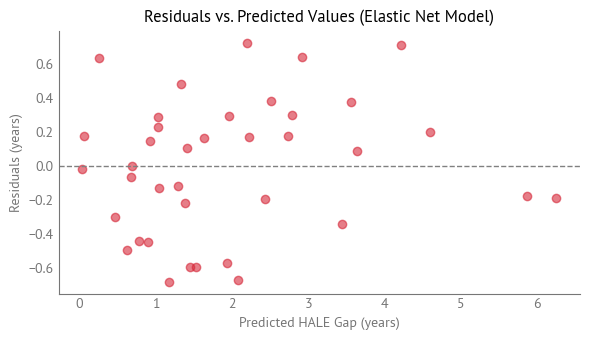

In [136]:
# Residual vs. Predicted values plot
plt.scatter(y_pred, residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Predicted HALE Gap (years)',
         ylabel='Residuals (years)',
         title='Residuals vs. Predicted Values (Elastic Net Model)')

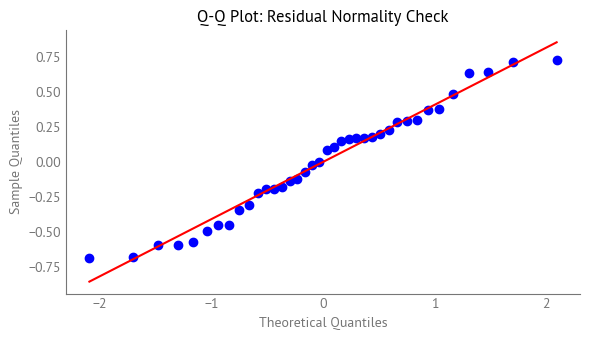

In [137]:
# Q-Q plot for residual normality
from scipy import stats

stats.probplot(residuals, dist="norm", plot=plt)
decorate(xlabel='Theoretical Quantiles',
         ylabel='Sample Quantiles',
         title='Q-Q Plot: Residual Normality Check')

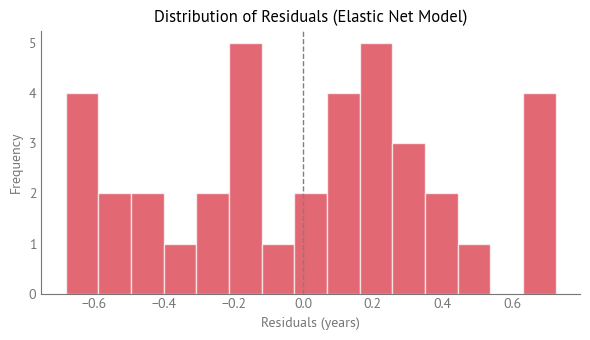

In [138]:
# Histogram of residuals
plt.hist(residuals, bins=15, color=AIBM_COLORS['crimson'], edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
decorate(xlabel='Residuals (years)',
         ylabel='Frequency',
         title='Distribution of Residuals (Elastic Net Model)')

In [139]:
# Residual statistics
residual_stats = pd.DataFrame({
    'Statistic': ['Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'Skewness', 'Kurtosis'],
    'Value': [
        residuals.mean(),
        residuals.std(),
        residuals.min(),
        residuals.quantile(0.25),
        residuals.median(),
        residuals.quantile(0.75),
        residuals.max(),
        stats.skew(residuals),
        stats.kurtosis(residuals)
    ]
})
residual_stats

,Statistic,Value
0,Mean,-1.694551e-16
1,Std,3.985420e-01
2,Min,-6.828808e-01
3,25%,-2.824962e-01
4,Median,4.323022e-02
5,75%,2.724205e-01
6,Max,7.248140e-01
7,Skewness,-1.484253e-02
8,Kurtosis,-8.621641e-01


In [140]:
# Identify potential outliers (residuals > 2 standard deviations)
outlier_threshold = 2 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]

outlier_df = pd.DataFrame({
    'Country': outliers.index,
    'Actual_HALE_Gap': y[outliers.index],
    'Predicted_HALE_Gap': y_pred[outliers.index],
    'Residual': outliers.values,
    'Abs_Residual': abs(outliers.values)
}).sort_values('Abs_Residual', ascending=False)

outlier_df if not outlier_df.empty else "No outliers detected (|residual| > 2 std)"

'No outliers detected (|residual| > 2 std)'

In [141]:
# Residuals by country (sorted by absolute residual)
residuals_by_country = pd.DataFrame({
    'Country': residuals.index,
    'Actual_HALE_Gap': y.values,
    'Predicted_HALE_Gap': y_pred,
    'Residual': residuals.values,
    'Abs_Residual': abs(residuals.values)
}).sort_values('Abs_Residual', ascending=False)

residuals_by_country.head(10)

,Country,Actual_HALE_Gap,Predicted_HALE_Gap,Residual,Abs_Residual
Country,,,,,
JPN,JPN,2.928847,2.204033,0.724814,0.724814
POL,POL,4.929800,4.217120,0.712681,0.712681
NZL,NZL,0.486508,1.169388,-0.682881,0.682881
CHL,CHL,1.408306,2.082298,-0.673992,0.673992
KOR,KOR,3.564595,2.924556,0.640040,0.640040
DNK,DNK,0.894501,0.257822,0.636679,0.636679
BEL,BEL,0.940556,1.535677,-0.595121,0.595121
DEU,DEU,0.862288,1.456663,-0.594375,0.594375
AUT,AUT,1.363167,1.935034,-0.571867,0.571867


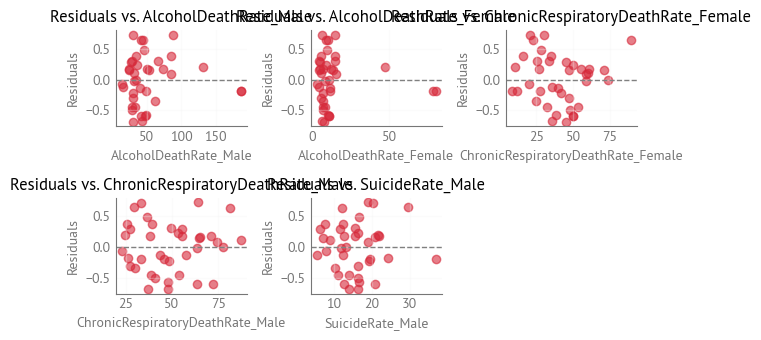

In [142]:
# Check for patterns: plot residuals vs. each predictor (top predictors by absolute coefficient)
# Get top predictors by absolute coefficient value
coef_abs = pd.Series(elastic_net_best_model.named_steps['elasticnet'].coef_, index=X.columns).abs()
top_predictors = coef_abs.nlargest(5).index.values

fig, axes = plt.subplots(2, 3)
axes = axes.flatten()

for i, pred in enumerate(top_predictors):
    if i < len(axes):
        axes[i].scatter(X[pred], residuals, color=AIBM_COLORS['crimson'], alpha=0.6)
        axes[i].axhline(y=0, color='gray', linestyle='--', linewidth=1)
        axes[i].set_xlabel(pred)
        axes[i].set_ylabel('Residuals')
        axes[i].set_title(f'Residuals vs. {pred}')
        axes[i].grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(top_predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()

### Check for Influential Observations

In [143]:
# For influence measures (Cook's distance, leverage), we fit an OLS model
# on the standardized data to calculate these diagnostics
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence

# Get standardized predictors (using the scaler from the pipeline)
X_std = primary_model.named_steps['scaler'].transform(X)

# Fit OLS model on standardized data
ols_model = OLS(y.values, X_std).fit()
influence = OLSInfluence(ols_model)

# Calculate Cook's distance and leverage
cooks_d = influence.cooks_distance[0]  # Cook's distance
leverage = influence.hat_matrix_diag  # Leverage (diagonal of hat matrix)

# Create DataFrame with influence measures
influence_df = pd.DataFrame({
    'Country': y.index,
    'Cook_Distance': cooks_d,
    'Leverage': leverage,
    'Residual': residuals.values,
    'Abs_Residual': abs(residuals.values)
}).sort_values('Cook_Distance', ascending=False)

influence_df

,Country,Cook_Distance,Leverage,Residual,Abs_Residual
6,COL,1.854637,0.906221,0.379579,0.379579
37,USA,0.877762,0.861645,0.161094,0.161094
27,MEX,0.803922,0.871401,-0.341391,0.341391
26,LVA,0.738130,0.865721,-0.178512,0.178512
23,KOR,0.496333,0.783316,0.640040,0.640040
24,LTU,0.480693,0.822684,-0.189926,0.189926
36,TUR,0.418225,0.813870,-0.121480,0.121480
22,JPN,0.181504,0.711746,0.724814,0.724814
34,SVN,0.175079,0.739942,0.173334,0.173334
7,CRI,0.156280,0.710743,0.294073,0.294073


In [144]:
# Identify influential observations
# Common thresholds:
# - Cook's distance > 4/n (where n is number of observations)
# - Leverage > 2*(p+1)/n (where p is number of predictors)
n = len(y)
p = X.shape[1]

cooks_threshold = 4 / n
leverage_threshold = 2 * (p + 1) / n

influential = influence_df[
    (influence_df['Cook_Distance'] > cooks_threshold) | 
    (influence_df['Leverage'] > leverage_threshold)
].copy()

print(f"Cook's distance threshold: {cooks_threshold:.4f}")
print(f"Leverage threshold: {leverage_threshold:.4f}")
print(f"\nNumber of influential observations: {len(influential)}")

influential if not influential.empty else "No influential observations detected"

Cook's distance threshold: 0.1053
Leverage threshold: 1.2632

Number of influential observations: 15


,Country,Cook_Distance,Leverage,Residual,Abs_Residual
6,COL,1.854637,0.906221,0.379579,0.379579
37,USA,0.877762,0.861645,0.161094,0.161094
27,MEX,0.803922,0.871401,-0.341391,0.341391
26,LVA,0.738130,0.865721,-0.178512,0.178512
23,KOR,0.496333,0.783316,0.640040,0.640040
24,LTU,0.480693,0.822684,-0.189926,0.189926
36,TUR,0.418225,0.813870,-0.121480,0.121480
22,JPN,0.181504,0.711746,0.724814,0.724814
34,SVN,0.175079,0.739942,0.173334,0.173334
7,CRI,0.156280,0.710743,0.294073,0.294073


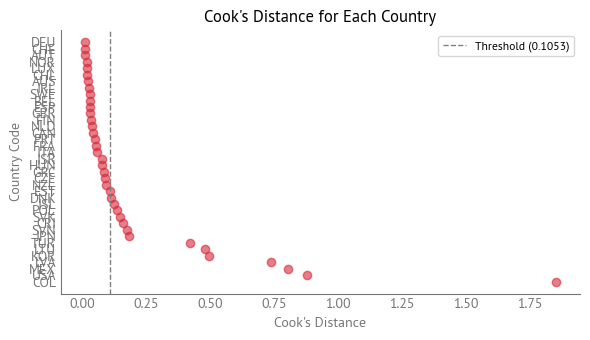

In [145]:
# Plot Cook's distance with country codes on y-axis
plt.scatter(influence_df['Cook_Distance'], range(len(influence_df)), 
           color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axvline(x=cooks_threshold, color='gray', linestyle='--', linewidth=1, label=f'Threshold ({cooks_threshold:.4f})')
plt.yticks(range(len(influence_df)), influence_df['Country'])
decorate(xlabel="Cook's Distance",
         ylabel='Country Code',
         title="Cook's Distance for Each Country")
plt.legend()

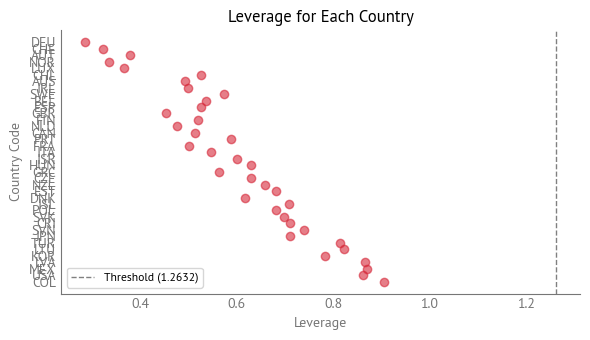

In [146]:
# Plot Leverage with country codes on y-axis
plt.scatter(influence_df['Leverage'], range(len(influence_df)), 
           color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axvline(x=leverage_threshold, color='gray', linestyle='--', linewidth=1, label=f'Threshold ({leverage_threshold:.4f})')
plt.yticks(range(len(influence_df)), influence_df['Country'])
decorate(xlabel='Leverage',
         ylabel='Country Code',
         title='Leverage for Each Country')
plt.legend()

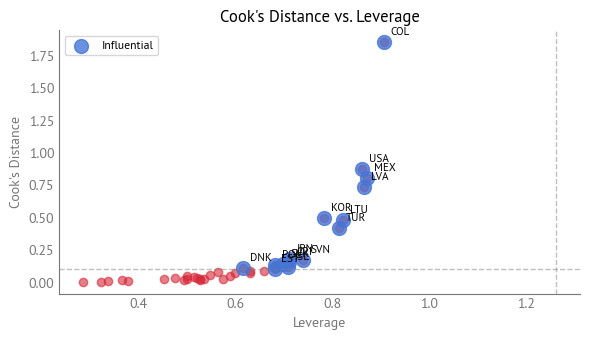

In [147]:
# Plot Cook's distance vs. Leverage
plt.scatter(influence_df['Leverage'], influence_df['Cook_Distance'], 
           color=AIBM_COLORS['crimson'], alpha=0.6)
plt.axhline(y=cooks_threshold, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=leverage_threshold, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Highlight influential observations
if not influential.empty:
    plt.scatter(influential['Leverage'], influential['Cook_Distance'], 
               color=AIBM_COLORS['blue'], s=100, alpha=0.8, label='Influential')
    # Add country labels for influential observations
    for idx, row in influential.iterrows():
        plt.annotate(row['Country'], 
                    (row['Leverage'], row['Cook_Distance']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

decorate(xlabel='Leverage',
         ylabel="Cook's Distance",
         title="Cook's Distance vs. Leverage")
plt.legend()

In [148]:
# Summary of influential observations
if not influential.empty:
    print("Influential Observations Summary:")
    print(f"Total: {len(influential)}")
    print(f"\nBy Cook's Distance > {cooks_threshold:.4f}:")
    high_cooks = influence_df[influence_df['Cook_Distance'] > cooks_threshold]
    print(f"  {len(high_cooks)} countries: {sorted(high_cooks['Country'].tolist())}")
    
    print(f"\nBy Leverage > {leverage_threshold:.4f}:")
    high_leverage = influence_df[influence_df['Leverage'] > leverage_threshold]
    print(f"  {len(high_leverage)} countries: {sorted(high_leverage['Country'].tolist())}")
else:
    print("No influential observations detected using standard thresholds.")

Influential Observations Summary:
Total: 15

By Cook's Distance > 0.1053:
  15 countries: ['COL', 'CRI', 'DNK', 'EST', 'ISL', 'JPN', 'KOR', 'LTU', 'LVA', 'MEX', 'POL', 'SVK', 'SVN', 'TUR', 'USA']

By Leverage > 1.2632:
  0 countries: []


## Summary: Indicator Analysis and Counterfactual Predictions

### Extract Elastic Net Coefficients

In [149]:
# Get coefficients from Elastic Net model (on standardized scale)
elastic_net_coefs_dict = dict(zip(X.columns, elastic_net_best_model.named_steps['elasticnet'].coef_))

# Get the scaler to understand standardization
scaler = elastic_net_best_model.named_steps['scaler']

### Calculate Summary for Each Indicator

In [150]:
# Group predictors by indicator
indicator_summary = []

# Indicators with both male and female values
# Get indicator names from predictor_dfs, excluding maternal mortality (female-only)
male_female_indicators = [name for name in predictor_dfs.keys() 
                          if name != 'MaternalMortalityRatio']

for indicator in male_female_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    if male_col in predictors.columns and female_col in predictors.columns:
        # Get coefficients (on standardized scale)
        coef_male = elastic_net_coefs_dict.get(male_col, 0)
        coef_female = elastic_net_coefs_dict.get(female_col, 0)
        
        # Calculate actual gap (Male - Female) from raw data
        # Use mean across all countries for summary
        male_mean = predictors[male_col].mean()
        female_mean = predictors[female_col].mean()
        actual_gap = male_mean - female_mean
        
        # Calculate predicted change in HALE gap if male = female
        # The model uses standardized predictors, so we need to:
        # 1. Calculate standardized values for current (male_mean, female_mean)
        # 2. Calculate standardized values if male = female (both = female_mean)
        # 3. Calculate the difference
        
        std_male = predictors[male_col].std()
        std_female = predictors[female_col].std()
        
        if std_male > 0 and std_female > 0:
            # Current standardized values (mean of column is used for standardization)
            # Since we're using the mean, current standardized values are approximately 0
            # But we need the actual standardized values for the mean values
            male_std_current = (male_mean - male_mean) / std_male  # = 0
            female_std_current = (female_mean - female_mean) / std_female  # = 0
            
            # If male = female (both equal to female_mean), calculate new standardized values
            male_std_new = (female_mean - male_mean) / std_male
            female_std_new = (female_mean - female_mean) / std_female  # = 0 (unchanged)
            
            # Change in standardized values
            delta_male_std = male_std_new - male_std_current
            delta_female_std = female_std_new - female_std_current  # = 0
            
            # Predicted change in HALE gap
            predicted_change = coef_male * delta_male_std + coef_female * delta_female_std
        else:
            predicted_change = 0
        
        indicator_summary.append({
            'Indicator': indicator,
            'Actual_Gap_Male_Minus_Female': actual_gap,
            'Coefficient_Male': coef_male,
            'Coefficient_Female': coef_female,
            'Predicted_Change_in_HALE_Gap_Years': predicted_change,
            'Male_Mean': male_mean,
            'Female_Mean': female_mean
        })

# Add female-only indicators
female_only_indicators = ['MaternalMortalityRatio']
for indicator in female_only_indicators:
    female_col = f'{indicator}_Female'
    
    if female_col in predictors.columns:
        coef_female = elastic_net_coefs_dict.get(female_col, 0)
        female_mean = predictors[female_col].mean()
        
        indicator_summary.append({
            'Indicator': indicator,
            'Actual_Gap_Male_Minus_Female': np.nan,  # No gap (female-only)
            'Coefficient_Male': np.nan,
            'Coefficient_Female': coef_female,
            'Predicted_Change_in_HALE_Gap_Years': np.nan,  # Not applicable
            'Male_Mean': np.nan,
            'Female_Mean': female_mean
        })

summary_df = pd.DataFrame(indicator_summary)
summary_df = summary_df.sort_values('Predicted_Change_in_HALE_Gap_Years', 
                                    key=abs, ascending=False, na_position='last')
summary_df

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years,Male_Mean,Female_Mean
3,AlcoholDeathRate,38.146029,1.577526,-0.859381,-1.512166,51.670267,13.524238
2,SuicideRate,10.905624,0.332246,-0.000000,-0.568491,15.683649,4.778025
1,ChronicRespiratoryDeathRate,8.664080,0.518961,-0.740040,-0.254910,48.772263,40.108183
5,RoadTrafficDeathRate,6.338193,0.159711,-0.048403,-0.174177,8.840793,2.502601
6,HomicideRate,4.687616,0.035441,-0.000000,-0.011533,5.908545,1.220929
0,CardioDeathRate,-21.457901,0.000000,0.153210,0.000000,287.082382,308.540284
4,PoisoningRate,0.317734,0.000000,0.000000,0.000000,0.516938,0.199204
7,U5MR,0.813698,-0.000000,-0.000000,0.000000,5.040331,4.226633
8,DiabetesDeathRate,-0.649469,0.000000,0.008769,0.000000,19.975597,20.625066
9,DrugDisorderDeathRate,2.717599,-0.000000,-0.000000,0.000000,4.438386,1.720787


### Interpretation

In [151]:
# Add interpretation column
summary_df['Interpretation'] = summary_df.apply(lambda row: 
    f"If {row['Indicator']} male value equals female value, "
    f"predicted HALE gap changes by {row['Predicted_Change_in_HALE_Gap_Years']:.3f} years"
    if not pd.isna(row['Predicted_Change_in_HALE_Gap_Years']) 
    else "Female-only indicator (no male comparison)", axis=1)

# Display formatted summary
display_cols = ['Indicator', 'Actual_Gap_Male_Minus_Female', 'Coefficient_Male', 
                'Coefficient_Female', 'Predicted_Change_in_HALE_Gap_Years', 'Interpretation']
summary_df[display_cols]

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years,Interpretation
3,AlcoholDeathRate,38.146029,1.577526,-0.859381,-1.512166,If AlcoholDeathRate male value equals female v...
2,SuicideRate,10.905624,0.332246,-0.000000,-0.568491,"If SuicideRate male value equals female value,..."
1,ChronicRespiratoryDeathRate,8.664080,0.518961,-0.740040,-0.254910,If ChronicRespiratoryDeathRate male value equa...
5,RoadTrafficDeathRate,6.338193,0.159711,-0.048403,-0.174177,If RoadTrafficDeathRate male value equals fema...
6,HomicideRate,4.687616,0.035441,-0.000000,-0.011533,If HomicideRate male value equals female value...
0,CardioDeathRate,-21.457901,0.000000,0.153210,0.000000,If CardioDeathRate male value equals female va...
4,PoisoningRate,0.317734,0.000000,0.000000,0.000000,If PoisoningRate male value equals female valu...
7,U5MR,0.813698,-0.000000,-0.000000,0.000000,"If U5MR male value equals female value, predic..."
8,DiabetesDeathRate,-0.649469,0.000000,0.008769,0.000000,If DiabetesDeathRate male value equals female ...
9,DrugDisorderDeathRate,2.717599,-0.000000,-0.000000,0.000000,If DrugDisorderDeathRate male value equals fem...


### Top Contributors to HALE Gap

In [152]:
# Show indicators with largest predicted impact (absolute value)
top_contributors = summary_df.sort_values('Predicted_Change_in_HALE_Gap_Years', 
                                          key=abs, ascending=False)
top_contributors[['Indicator', 'Actual_Gap_Male_Minus_Female', 
                  'Coefficient_Male', 'Coefficient_Female', 
                  'Predicted_Change_in_HALE_Gap_Years']]

,Indicator,Actual_Gap_Male_Minus_Female,Coefficient_Male,Coefficient_Female,Predicted_Change_in_HALE_Gap_Years
3,AlcoholDeathRate,38.146029,1.577526,-0.859381,-1.512166
2,SuicideRate,10.905624,0.332246,-0.000000,-0.568491
1,ChronicRespiratoryDeathRate,8.664080,0.518961,-0.740040,-0.254910
5,RoadTrafficDeathRate,6.338193,0.159711,-0.048403,-0.174177
6,HomicideRate,4.687616,0.035441,-0.000000,-0.011533
0,CardioDeathRate,-21.457901,0.000000,0.153210,0.000000
4,PoisoningRate,0.317734,0.000000,0.000000,0.000000
7,U5MR,0.813698,-0.000000,-0.000000,0.000000
8,DiabetesDeathRate,-0.649469,0.000000,0.008769,0.000000
9,DrugDisorderDeathRate,2.717599,-0.000000,-0.000000,0.000000


## Predictor Importance Analysis

### Calculate Feature Importance

In [153]:
# Feature importance = |coefficient| × std(predictor)
# This measures the contribution of each predictor to the HALE gap variation
# Since predictors are standardized, we multiply by the original standard deviation
# to get importance on the original scale

predictor_importance = []

for predictor in X.columns:
    coef = elastic_net_coefs_dict.get(predictor, 0)
    
    # Get the original (unstandardized) standard deviation
    # The scaler was fit on X, so we can get the std from predictors DataFrame
    if predictor in predictors.columns:
        std_original = predictors[predictor].std()
        importance = abs(coef) * std_original
    else:
        std_original = 0
        importance = 0
    
    predictor_importance.append({
        'Predictor': predictor,
        'Coefficient': coef,
        'Std_Original': std_original,
        'Importance': importance
    })

importance_df = pd.DataFrame(predictor_importance).sort_values('Importance', ascending=False)
importance_df

,Predictor,Coefficient,Std_Original,Importance
6,AlcoholDeathRate_Male,1.577526,39.794802,62.777326
1,CardioDeathRate_Female,0.153210,175.710878,26.920652
7,AlcoholDeathRate_Female,-0.859381,17.253014,14.826920
3,ChronicRespiratoryDeathRate_Female,-0.740040,18.427862,13.637347
2,ChronicRespiratoryDeathRate_Male,0.518961,17.638881,9.153896
22,UnintentionalInjuriesDeathRate_Female,-0.296588,10.464067,3.103521
4,SuicideRate_Male,0.332246,6.373638,2.117618
14,MaternalMortalityRatio_Female,0.105052,12.246133,1.286485
10,RoadTrafficDeathRate_Male,0.159711,5.811777,0.928205
12,HomicideRate_Male,0.035441,14.404683,0.510514


### Visualize Predictor Importance

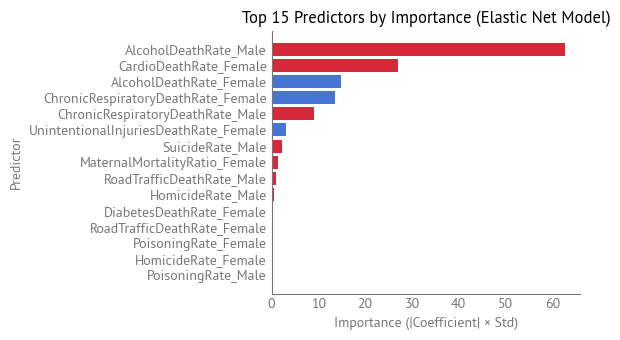

In [154]:
# Create bar chart of top predictors by importance
top_n = 15
top_importance = importance_df.head(top_n)

colors = [AIBM_COLORS['crimson'] if x > 0 else AIBM_COLORS['blue'] 
          for x in top_importance['Coefficient']]
plt.barh(range(len(top_importance)), top_importance['Importance'], color=colors)
plt.yticks(range(len(top_importance)), top_importance['Predictor'])
plt.gca().invert_yaxis()
decorate(xlabel='Importance (|Coefficient| × Std)',
         ylabel='Predictor',
         title=f'Top {top_n} Predictors by Importance (Elastic Net Model)')

### Importance by Indicator

In [155]:
# Aggregate importance by indicator (sum of male and female importance)
indicator_importance = {}

for indicator in male_female_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    male_imp = importance_df[importance_df['Predictor'] == male_col]['Importance'].values
    female_imp = importance_df[importance_df['Predictor'] == female_col]['Importance'].values
    
    if len(male_imp) > 0 and len(female_imp) > 0:
        total_importance = male_imp[0] + female_imp[0]
        indicator_importance[indicator] = {
            'Male_Importance': male_imp[0],
            'Female_Importance': female_imp[0],
            'Total_Importance': total_importance
        }

# Add female-only indicators
for indicator in female_only_indicators:
    female_col = f'{indicator}_Female'
    female_imp = importance_df[importance_df['Predictor'] == female_col]['Importance'].values
    
    if len(female_imp) > 0:
        indicator_importance[indicator] = {
            'Male_Importance': np.nan,
            'Female_Importance': female_imp[0],
            'Total_Importance': female_imp[0]
        }

indicator_importance_df = pd.DataFrame(indicator_importance).T
indicator_importance_df = indicator_importance_df.sort_values('Total_Importance', ascending=False)
indicator_importance_df

,Male_Importance,Female_Importance,Total_Importance
AlcoholDeathRate,62.777326,14.826920,77.604246
CardioDeathRate,0.000000,26.920652,26.920652
ChronicRespiratoryDeathRate,9.153896,13.637347,22.791244
UnintentionalInjuriesDeathRate,0.000000,3.103521,3.103521
SuicideRate,2.117618,0.000000,2.117618
MaternalMortalityRatio,NaN,1.286485,1.286485
RoadTrafficDeathRate,0.928205,0.073225,1.001430
HomicideRate,0.510514,0.000000,0.510514
DiabetesDeathRate,0.000000,0.095941,0.095941
PoisoningRate,0.000000,0.000000,0.000000


### Visualize Indicator Importance

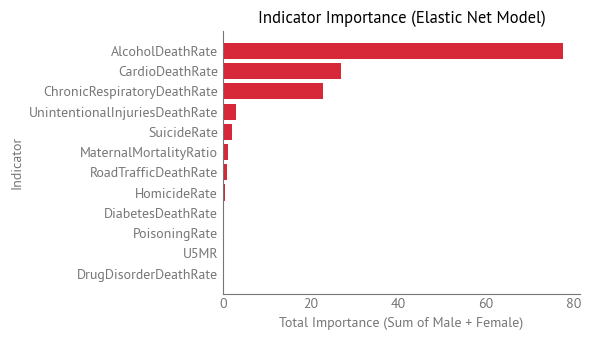

In [156]:
# Bar chart of indicator-level importance
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_importance_df))]
plt.barh(range(len(indicator_importance_df)), indicator_importance_df['Total_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_importance_df)), indicator_importance_df.index)
plt.gca().invert_yaxis()
decorate(xlabel='Total Importance (Sum of Male + Female)',
         ylabel='Indicator',
         title='Indicator Importance (Elastic Net Model)')

## Permutation Importance Analysis

Permutation importance measures how much the model's performance decreases when a feature's values are randomly shuffled. This provides an alternative measure of feature importance that is model-agnostic and accounts for feature interactions.

### Calculate Permutation Importance

In [157]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance using the primary model
# Use the same cross-validation setup for consistency
perm_importance = permutation_importance(
    primary_model, X, y,
    scoring='r2',
    n_repeats=10,  # Number of times to permute each feature
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with permutation importance results
perm_importance_df = pd.DataFrame({
    'Predictor': X.columns,
    'Permutation_Importance_Mean': perm_importance.importances_mean,
    'Permutation_Importance_Std': perm_importance.importances_std
}).sort_values('Permutation_Importance_Mean', ascending=False)

perm_importance_df

,Predictor,Permutation_Importance_Mean,Permutation_Importance_Std
6,AlcoholDeathRate_Male,2.136296,0.318337
7,AlcoholDeathRate_Female,0.619440,0.109543
3,ChronicRespiratoryDeathRate_Female,0.461031,0.062623
2,ChronicRespiratoryDeathRate_Male,0.223184,0.034804
4,SuicideRate_Male,0.090093,0.026353
22,UnintentionalInjuriesDeathRate_Female,0.081458,0.021944
10,RoadTrafficDeathRate_Male,0.029064,0.006706
1,CardioDeathRate_Female,0.020698,0.006475
14,MaternalMortalityRatio_Female,0.012986,0.005071
12,HomicideRate_Male,0.002549,0.001584


### Visualize Permutation Importance

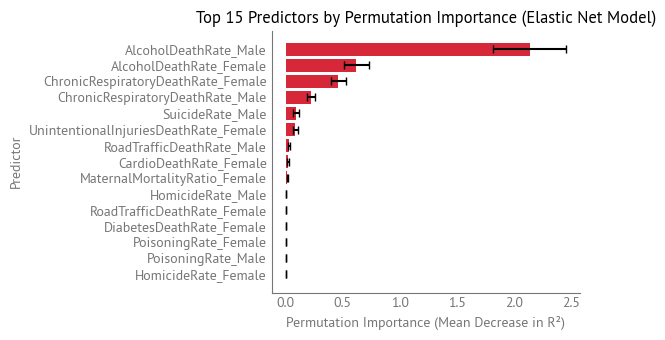

In [158]:
# Create bar chart of top predictors by permutation importance
top_n = 15
top_perm_importance = perm_importance_df.head(top_n)

plt.barh(range(len(top_perm_importance)), 
         top_perm_importance['Permutation_Importance_Mean'],
         xerr=top_perm_importance['Permutation_Importance_Std'],
         color=AIBM_COLORS['crimson'],
         capsize=3)
plt.yticks(range(len(top_perm_importance)), top_perm_importance['Predictor'])
plt.gca().invert_yaxis()
decorate(xlabel='Permutation Importance (Mean Decrease in R²)',
         ylabel='Predictor',
         title=f'Top {top_n} Predictors by Permutation Importance (Elastic Net Model)')

### Compare Permutation Importance with Coefficient-Based Importance

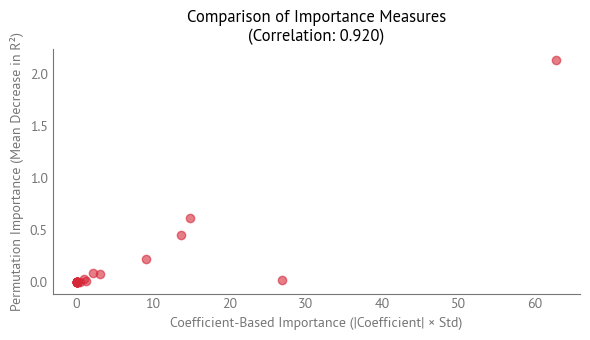

In [159]:
# Merge permutation importance with coefficient-based importance
comparison_df = importance_df.merge(
    perm_importance_df[['Predictor', 'Permutation_Importance_Mean']],
    on='Predictor',
    how='inner'
)

# Calculate correlation between the two importance measures
correlation = comparison_df['Importance'].corr(comparison_df['Permutation_Importance_Mean'])

# Create scatter plot comparing the two importance measures
plt.scatter(comparison_df['Importance'], 
           comparison_df['Permutation_Importance_Mean'],
           color=AIBM_COLORS['crimson'], alpha=0.6)
decorate(xlabel='Coefficient-Based Importance (|Coefficient| × Std)',
         ylabel='Permutation Importance (Mean Decrease in R²)',
         title=f'Comparison of Importance Measures\n(Correlation: {correlation:.3f})')

### Permutation Importance by Indicator

In [160]:
# Aggregate permutation importance by indicator (sum of male and female importance)
indicator_perm_importance = {}

for indicator in male_female_indicators:
    male_col = f'{indicator}_Male'
    female_col = f'{indicator}_Female'
    
    male_perm = perm_importance_df[perm_importance_df['Predictor'] == male_col]['Permutation_Importance_Mean'].values
    female_perm = perm_importance_df[perm_importance_df['Predictor'] == female_col]['Permutation_Importance_Mean'].values
    
    if len(male_perm) > 0 and len(female_perm) > 0:
        total_perm_importance = male_perm[0] + female_perm[0]
        indicator_perm_importance[indicator] = {
            'Male_Perm_Importance': male_perm[0],
            'Female_Perm_Importance': female_perm[0],
            'Total_Perm_Importance': total_perm_importance
        }

# Add female-only indicators
for indicator in female_only_indicators:
    female_col = f'{indicator}_Female'
    female_perm = perm_importance_df[perm_importance_df['Predictor'] == female_col]['Permutation_Importance_Mean'].values
    
    if len(female_perm) > 0:
        indicator_perm_importance[indicator] = {
            'Male_Perm_Importance': np.nan,
            'Female_Perm_Importance': female_perm[0],
            'Total_Perm_Importance': female_perm[0]
        }

indicator_perm_importance_df = pd.DataFrame(indicator_perm_importance).T
indicator_perm_importance_df = indicator_perm_importance_df.sort_values('Total_Perm_Importance', ascending=False)
indicator_perm_importance_df

,Male_Perm_Importance,Female_Perm_Importance,Total_Perm_Importance
AlcoholDeathRate,2.136296,0.619440,2.755736
ChronicRespiratoryDeathRate,0.223184,0.461031,0.684215
SuicideRate,0.090093,0.000000,0.090093
UnintentionalInjuriesDeathRate,0.000000,0.081458,0.081458
RoadTrafficDeathRate,0.029064,0.001533,0.030597
CardioDeathRate,0.000000,0.020698,0.020698
MaternalMortalityRatio,NaN,0.012986,0.012986
HomicideRate,0.002549,0.000000,0.002549
DiabetesDeathRate,0.000000,0.000342,0.000342
PoisoningRate,0.000000,0.000000,0.000000


### Visualize Indicator-Level Permutation Importance

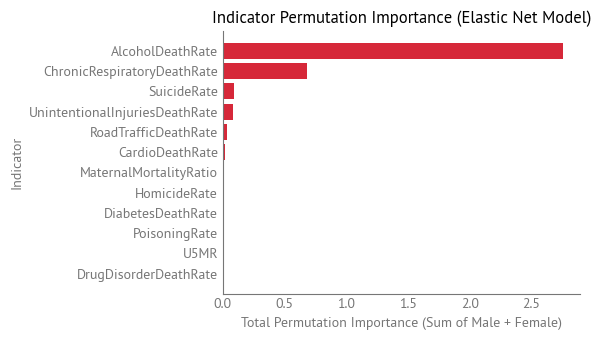

In [161]:
# Bar chart of indicator-level permutation importance
colors_bar = [AIBM_COLORS['crimson'] for _ in range(len(indicator_perm_importance_df))]
plt.barh(range(len(indicator_perm_importance_df)), 
         indicator_perm_importance_df['Total_Perm_Importance'], 
         color=colors_bar)
plt.yticks(range(len(indicator_perm_importance_df)), indicator_perm_importance_df.index)
plt.gca().invert_yaxis()
decorate(xlabel='Total Permutation Importance (Sum of Male + Female)',
         ylabel='Indicator',
         title='Indicator Permutation Importance (Elastic Net Model)')

### Compare Coefficient-Based vs Permutation Importance by Indicator

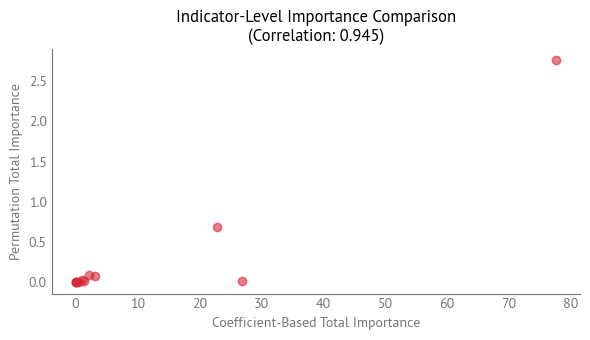

In [162]:
# Merge indicator-level importance from both methods
indicator_comparison = indicator_importance_df.merge(
    indicator_perm_importance_df[['Total_Perm_Importance']],
    left_index=True,
    right_index=True,
    how='inner'
)

# Calculate correlation
indicator_correlation = indicator_comparison['Total_Importance'].corr(
    indicator_comparison['Total_Perm_Importance']
)

# Create scatter plot
plt.scatter(indicator_comparison['Total_Importance'],
           indicator_comparison['Total_Perm_Importance'],
           color=AIBM_COLORS['crimson'], alpha=0.6)
decorate(xlabel='Coefficient-Based Total Importance',
         ylabel='Permutation Total Importance',
         title=f'Indicator-Level Importance Comparison\n(Correlation: {indicator_correlation:.3f})')